<a href="https://colab.research.google.com/github/7235SYXD/Apple-App-Store/blob/main/DSP_on_Real_Estate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell 1 — Library Installation

This cell helps us to install all the third-party Python packages which are used for executing the entire pipeline

| Package | Purpose |
|---|---|
| `kagglehub` | Dataset directly downloaded from kaggle |
| `catboost` | Gradient boosting with native categorical handling |
| `shap` | Model interpretability via Shap values |
| `optuna` | Bayesian hyperparameter optimisation |
| `vaderSentiment` | Sentiment analysis for listing descriptions |
| `yake` | Unsupervised keyword extraction from listing text |
| `textstat` | Flesch readability scores for NLP feature engineering |




In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL LIBRARIES                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

"""
Packages installed:
    kagglehub       : As the size of the datasets are too large to upload we are using
                      kagglehub link to directly upload the CSV to avoid the upload limit.
    catboost        : Yandex CatBoost are used as the primary base learner for gradient
                      boosted trees.
    shap            : SHapley Additive is used for model interpretability.
    optuna          : Bayesian hyperparameter optimization with Tree-structured
                      Parzen Estimator is used for all the 4 model tunning.
    vaderSentiment  : VADER sentiment analyser is used to extract compound, positive,
                      negative scores per listing.
    yake            : Yet Another Keyword Extractor used to extract the top 3 key
                      phrases per listing description.
    textstat        : Flesch Reading and Flesch-Kincaid grade are calculated and is
                      used to measure listing description readability.
"""

import subprocess, sys
for lib in ["kagglehub","catboost","shap","optuna",
            "vaderSentiment","yake","textstat"]:
    subprocess.run([sys.executable,"-m","pip","install",lib,"-q"])
print("All libraries installed.")


All libraries installed.


# Cell 2 — Google Drive Setup

Google drive allows us to mount and create a directory to save all the **4 notebooks**. All the output i.e, cleaned CSVs, model checkpoints, plots and results tables are written to this directory so that notebooks can exchange the data without re-downloading or re-cleaning.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GOOGLE DRIVE                                           ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Why Google Drive:
    Colab sessions are ephemeral — All the content files and in-memory data
    is lost when the session ends or the runtime restarts. Saving it to
    google drive helps us to make the outputs persistent across all the sessions
    and are used to share among the 4 notebooks.

    Mounts Google Drive and creates the shared output directory.

Sets:
    SAVE_DIR (str) : absolute path to the shared Drive directory.
"""

import os, shutil
from google.colab import drive, files

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/RealEstate_TXNY"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Mounted at /content/drive
Save directory: /content/drive/MyDrive/RealEstate_TXNY


# Cell 3 — Import All Libraries

Imports all the libraries used across all the **4 notebooks**.

- A cell where all the libraries and packages are available.
- Predictable import order.

**Random seed is fixed here (SEED = 42)** which ensures full reproducibility:
train/test splits, model initialisations, and optuna hyperparameters uses this fixed random seed.

| Category | Libraries |
|---|---|
| Data | `numpy`, `pandas` |
| Visualisation | `matplotlib`, `seaborn` |
| Machine Learning | `sklearn` (imputer, scaler, RF, metrics) |
| Gradient Boosting | `catboost`, `xgboost` |
| Deep Learning | `tensorflow`, `keras` |
| Hyperparameter Tuning | `optuna` |
| Interpretability | `shap` |
| NLP | `vaderSentiment`, `yake`, `textstat` |





In [ ]:
# ╔════════════════════════════════════════════════════╗
# ║  CELL 3 — IMPORT ALL LIBRARIES                     ║
# ╚════════════════════════════════════════════════════╝

"""
Imports all libraries and sets global constants.

Global constants set in this cell:
    SEED (42) : This random seed is used for all operations which helps to ensure
                reproducibility. This random seed is applied to numpy, tensorflow,
                train_test_split, all sklearn models, optuna samplers, KFold splits.

Key imports by category:
    Data wrangling  : numpy, pandas, gc (garbage collection for RAM management)
    Visualisation   : matplotlib.pyplot, seaborn, gridspec
    Preprocessing   : StandardScaler, IterativeImputer (MICE), LabelEncoder
    Models          : RandomForestRegressor, CatBoostRegressor, keras (MLP),
                      HistGradientBoostingRegressor
    Metrics         : r2_score, mean_squared_error, mean_absolute_error,
                      roc_auc_score, f1_score, classification_report
    Tuning          : optuna (TPE sampler, MedianPruner)
    Interpretability: shap (TreeExplainer, permutation_importance)
    NLP             : SentimentIntensityAnalyzer (VADER), yake, textstat

"""

import os
import re
import warnings
from pathlib import Path
import gc # Import the garbage collection module

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib.ticker as mticker

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    accuracy_score,
)

# Gradient boosting
!pip install catboost
from catboost import CatBoostRegressor, CatBoostClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hyperparameter tuning
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretability
import shap

# NLP
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
!pip install yake
import yake
!pip install textstat
import textstat

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("All libraries imported successfully.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  tensorflow : {tf.__version__}")
print(f"  sklearn    : OK")
print("=" * 60)

All libraries imported successfully.
  pandas     : 2.2.2
  numpy      : 2.0.2
  tensorflow : 2.20.0
  sklearn    : OK


# Cell 4 — PII Column Registry & State Normalisation Map

## Why PII Removal Matters

The four datasets which i am working are publicly sourced from kaggle which contains columns that could identify individuals like property owners, agents, brokers. These are removed before processing with the codes to comply with the ethical data science principles and the project's data management plan.

## PII Columns Identified

| Dataset | PII Column | Reason for Removal |
|---|---|---|
| SAKIB | `brokered_by` | Agent/broker name — personal identifier |
| SAKIB | `street` | Full property street address — location PII |
| SAKIB | `prev_sold_date` | Historical transaction — quasi-PII |
| POLARTECH | `property_url` | URL contains listing agent identity |
| POLARTECH | `broker_id`, `agent_name`, `agency_name` | Personal/business identifiers |
| POLARTECH | `address`, `street_name`, `apartment` | Full/partial address — PII |
| TX/NY NLP | `address`, `agent`, `mls_id` | Address + agent identity |

## STATE_MAP Fix

The two datasets i.e, Sakib and Polartech store state names in different format
like SAKIB stores state names as (`"Texas"` , `"New York"`) while POLARTECH stores state names in abbreviations (`"TX"` , `"NY"`). Due to this reason we have to normalize and filter to `state == "TX"` which will help us to retain the rows which we are working on. So `STATE_MAP` dictionary and
`normalise_state()` function fixes this problem before any merge.





In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — PII COLUMN REGISTRY + STATE MAP                        ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Defines PII column lists and state normalisation.

PII lists defined:
    PII_COLS_SAKIB (list)     : 3 columns to drop from SAKIB before processing.
                                brokered_by (agent/broker name), street (property address),
                                prev_sold_date (can identify owner transaction history)
    PII_COLS_POLARTECH (list) : 9 columns to drop from POLARTECH.
                                property_url, property_id, broker_id, agent_name,
                                agency_name, address, street_name, apartment, agent_phone
    PII_COLS_NLP (list)       : 6 columns to drop from TX/NY NLP datasets.
                                 address, street, agent

Functions defined:
    drop_pii_columns(df, pii_list, dataset_name) -> pd.DataFrame
        Drops PII columns that exist in the DataFrame.
        Reports dropped columns and safely ignores missing ones.
        Args:
            df           : input DataFrame
            pii_list     : list of column names to attempt to drop
            dataset_name : string label for print output
        Returns:
            DataFrame with PII columns removed.

    normalise_state -> pd.Series
        Converts state names to standard 2-letter abbreviations.
        Handles: full names ("Texas" → "TX"), already-abbreviated ("TX" → "TX"),
                 lowercase ("florida" → "FL"), mixed case ("New York" → "NY").
        Args:
            series : pd.Series of raw state strings
        Returns:
            pd.Series of 2-letter state abbreviations.

STATE_MAP (dict):
    Maps 50 US state full names + DC to 2-letter USPS abbreviations.

Validation:
    Tests normalise_state() on ["Texas", "New York", "CA", "florida"].
    Expected output: ["TX", "NY", "CA", "FL"].
"""

# PII columns per dataset (lowercase column names after normalisation)
PII_COLS_SAKIB = [
    "brokered_by",     # agent / broker name — PII
    "street",          # full street address — PII
    "prev_sold_date",  # transaction history — quasi-PII
]

PII_COLS_POLARTECH = [
    "property_url",    # URL can identify listing owner — PII
    "property_id",     # internal ID — quasi-PII
    "broker_id",       # broker identifier — PII
    "agent_name",      # personal name — PII
    "agency_name",     # business name — quasi-PII
    "address",         # full street address — PII
    "street_name",     # partial address — PII
    "apartment",       # unit number — PII
    "agent_phone",     # agent phone number - PII
]

PII_COLS_NLP = [
    "address",         # full address — PII
    "street",          # street name — PII
    "agent",           # agent name — PII
    "listing_agent",   # agent name — PII
    "mls_id",          # MLS listing ID — quasi-PII
    "listing_id",      # listing identifier — quasi-PII
]

def drop_pii_columns(df, pii_list, dataset_name):
    """
    Drop PII columns from a DataFrame.
    """
    found = [c for c in pii_list if c in df.columns]
    not_found = [c for c in pii_list if c not in df.columns]
    if found:
        df = df.drop(columns=found)
        print(f"  {dataset_name} — PII dropped: {found}")
    if not_found:
        print(f"  {dataset_name} — PII not present (safe): {not_found}")
    return df

# ── STATE MAP ────────────────────────────────────────────────────────────────
STATE_MAP = {
    "ALABAMA":"AL","ALASKA":"AK","ARIZONA":"AZ","ARKANSAS":"AR",
    "CALIFORNIA":"CA","COLORADO":"CO","CONNECTICUT":"CT","DELAWARE":"DE",
    "FLORIDA":"FL","GEORGIA":"GA","HAWAII":"HI","IDAHO":"ID",
    "ILLINOIS":"IL","INDIANA":"IN","IOWA":"IA","KANSAS":"KS",
    "KENTUCKY":"KY","LOUISIANA":"LA","MAINE":"ME","MARYLAND":"MD",
    "MASSACHUSETTS":"MA","MICHIGAN":"MI","MINNESOTA":"MN","MISSISSIPPI":"MS",
    "MISSOURI":"MO","MONTANA":"MT","NEBRASKA":"NE","NEVADA":"NV",
    "NEW HAMPSHIRE":"NH","NEW JERSEY":"NJ","NEW MEXICO":"NM","NEW YORK":"NY",
    "NORTH CAROLINA":"NC","NORTH DAKOTA":"ND","OHIO":"OH","OKLAHOMA":"OK",
    "OREGON":"OR","PENNSYLVANIA":"PA","RHODE ISLAND":"RI","SOUTH CAROLINA":"SC",
    "SOUTH DAKOTA":"SD","TENNESSEE":"TN","TEXAS":"TX","UTAH":"UT",
    "VERMONT":"VT","VIRGINIA":"VA","WASHINGTON":"WA","WEST VIRGINIA":"WV",
    "WISCONSIN":"WI","WYOMING":"WY","DISTRICT OF COLUMBIA":"DC",
}
for abbr in ["AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID",
             "IL","IN","IA","KS","KY","LA","ME","MD","MA","MI","MN","MS",
             "MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH","OK",
             "OR","PA","RI","SC","SD","TN","TX","UT","VT","VA","WA","WV",
             "WI","WY","DC"]:
    STATE_MAP[abbr] = abbr

def normalise_state(series):
    """Convert any state format to 2-letter abbreviation."""
    return (series.astype(str).str.strip().str.upper()
            .map(lambda x: STATE_MAP.get(x, x)))

# Verify STATE_MAP
test_states = pd.Series(["Texas", "New York", "CA", "florida"])
for raw, norm in zip(test_states, normalise_state(test_states)):
    print(f"  '{raw}' → '{norm}'")
print("State normalisation")
print("PII column registry is defined ")


  'Texas' → 'TX'
  'New York' → 'NY'
  'CA' → 'CA'
  'florida' → 'FL'
State normalisation
PII column registry is defined 


# Cell 5 — Download All 4 Datasets via kagglehub

Downloads all four Kaggle datasets using `kagglehub`.

| # | Dataset | Kaggle Slug | Size | NLP? |
|---|---|---|---|---|
| 1 | SAKIB | `ahmedshahriarsakib/usa-real-estate-dataset` | 2.2M rows | ✗ |
| 2 | POLARTECH | `polartech/500000-us-homes-data-for-sale-properties` | ~600K rows | ✗ |
| 3 | TEXAS 2026 | `jahnavikachhia23/texas-residential-real-estate-intelligence-2026` | ~12K rows | ✓ |
| 4 | NEW YORK 2026 | `kanchana1990/new-york-real-estate-data-2026` | ~9K rows | ✓ |

>**Why these 4 datasets?**
*   SAKIB and POLARTECH provide the large structured corpus (price, beds, baths, sqft).
*   TEXAS and NEW YORK provide with the listing description text needed for NLP feature extraction.
*   Restricting to TX+NY ensures **100% NLP coverage** — if the full 50-state corpus were used, ≤3% of rows would have descriptions.
*   **kagglehub caches downloads** — subsequent Colab sessions skip the download and load from cache in seconds.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — DOWNLOAD ALL 4 DATASETS                                ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Download all the 4 datasets via kagglehub link.

Design decision — TX+NY only corpus:
    If we use the full 50 state national corpus which contains ~2.7M rows, but
    we have only 2-5% listing descriptions. Due to which the NLP features will
    receive near-identical values for 95% of rows, making the ablation study
    show zero. So i have restricted it to two state which gives 100% NLP
    coverage and enable meaningful ablation comparision.

Variables set:
    path_sakib     (str) : local cache path for SAKIB dataset
    path_polartech (str) : local cache path for POLARTECH dataset
    path_texas     (str) : local cache path for TEXAS 2026 NLP dataset
    path_newyork   (str) : local cache path for NEW YORK 2026 NLP dataset
"""

print("Downloading 4 datasets ...")
path_sakib    = kagglehub.dataset_download("ahmedshahriarsakib/usa-real-estate-dataset")
path_polartech= kagglehub.dataset_download("polartech/500000-us-homes-data-for-sale-properties")
path_texas    = kagglehub.dataset_download("jahnavikachhia23/texas-residential-real-estate-intelligence-2026")
path_newyork  = kagglehub.dataset_download("kanchana1990/new-york-real-estate-data-2026")
print(f"  SAKIB     : {path_sakib}")
print(f"  POLARTECH : {path_polartech}")
print(f"  TEXAS     : {path_texas}")
print(f"  NEW YORK  : {path_newyork}")

100%|██████████| 38.2M/38.2M [00:00<00:00, 94.4MB/s]

Extracting files...


100%|██████████| 34.6M/34.6M [00:00<00:00, 65.2MB/s]

Extracting files...


100%|██████████| 3.46M/3.46M [00:00<00:00, 83.5MB/s]

Extracting files...


100%|██████████| 3.11M/3.11M [00:00<00:00, 49.8MB/s]

Extracting files...
  SAKIB     : /root/.cache/kagglehub/datasets/ahmedshahriarsakib/usa-real-estate-dataset/versions/25
  POLARTECH : /root/.cache/kagglehub/datasets/polartech/500000-us-homes-data-for-sale-properties/versions/1
  TEXAS     : /root/.cache/kagglehub/datasets/jahnavikachhia23/texas-residential-real-estate-intelligence-2026/versions/1
  NEW YORK  : /root/.cache/kagglehub/datasets/kanchana1990/new-york-real-estate-data-2026/versions/1


# Cell 6 — Load CSV Files into DataFrames

Each downloaded dataset folder loads the primary CSV into pandas Dataframe.
Then `find_csv()` helper walks through the downloaded directory because kagglehub sometimes creates nested subdirectories.

After all the downloading is done print the raw shape and column names of all
the 4 datasets for an initial audit before any cleaning starts.





In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — LOAD CSV FILES                                         ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Reads the primary CSV from each kagglehub download directory.

Function defined:
    find_csv(folder) -> str
        Walks a directory tree recursively and returns the path of the
        first .csv file found. Handles nested subdirectory structures
        created by kagglehub.
        Args:
            folder (str) : root directory to search
        Returns:
            Absolute path to first .csv file found.
        Raises:
            FileNotFoundError if no .csv is found.

DataFrames loaded:
    df_sakib     : 2,226,382 rows × 10 cols (national, no descriptions)
    df_polartech : ~600,000  rows × 28 cols (national, no descriptions)
    df_texas     : ~12,137   rows × 13 cols (TX only, has descriptions)
    df_newyork   : ~8,273    rows × 11 cols (NY only, has descriptions)

Constants set:
    TEXAS_DESC   (str) : column name for description in Texas dataset
    NEWYORK_DESC (str) : column name for description in New York dataset

Output:
    Prints shape and column list for each dataset for manual verification.
"""

def find_csv(folder):
    for root, dirs, fs in os.walk(folder):
        for f in fs:
            if f.endswith(".csv"):
                return os.path.join(root, f)
    raise FileNotFoundError(f"No CSV in: {folder}")

df_sakib     = pd.read_csv(find_csv(path_sakib),     low_memory=False)
df_polartech = pd.read_csv(find_csv(path_polartech), low_memory=False)
df_texas     = pd.read_csv(find_csv(path_texas),     low_memory=False)
df_newyork   = pd.read_csv(find_csv(path_newyork),   low_memory=False)

for name, df in [("SAKIB",df_sakib),("POLARTECH",df_polartech),
                  ("TEXAS",df_texas),("NEW YORK",df_newyork)]:
    print(f"{name:10s}: {df.shape[0]:,} rows x {df.shape[1]} cols")
    print(f"  Columns: {list(df.columns)}")

TEXAS_DESC   = "description"
NEWYORK_DESC = "description"

SAKIB     : 2,226,382 rows x 12 cols
  Columns: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']
POLARTECH : 600,000 rows x 28 cols
  Columns: ['property_url', 'property_id', 'address', 'street_name', 'apartment', 'city', 'state', 'latitude', 'longitude', 'postcode', 'price', 'bedroom_number', 'bathroom_number', 'price_per_unit', 'living_space', 'land_space', 'land_space_unit', 'broker_id', 'property_type', 'property_status', 'year_build', 'total_num_units', 'listing_age', 'RunDate', 'agency_name', 'agent_name', 'agent_phone', 'is_owned_by_zillow']
TEXAS     : 12,137 rows x 13 cols
  Columns: ['type', 'sub_type', 'text', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built', 'Price_Per_SqFt']
NEW YORK  : 8,273 rows x 11 cols
  Columns: ['type', 'sub_type', 'text', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage'


# Cell 7 — Full Cleaning Audit: SAKIB

In this i have applied a 10-step cleaning pipeline where every step reports row
count before and after so the data lineage is fully traceable.

## Cleaning Steps

| Step | Operation | Why |
|---|---|---|
| 1 | Dataset size audit | Establish baseline before any changes |
| 2 | PII removal | Remove broker name, street address, sale history |
| 3 | Deduplicate exact rows | Removes 100% identical duplicates |
| 4 | Drop null price/state | Cannot impute the regression target or state key |
| 5 | STATE_MAP normalisation | Fixes "Texas" → "TX" bug in SAKIB |
| 6 | IQR price filtering (3.0×) | Removes impossible/extreme prices; floor at $10K |
| 7 | Log price transform | Reduces right-skewness; models respond better to log scale |
| 8 | MICE imputation | Fills missing beds/baths/sqft using iterative chained equations |
| 9 | Range clipping | Clips beds/baths to 0–20 (removes data entry errors) |
| 10 | City normalisation | Converts city names to uppercase for consistent merging |







In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — FULL CLEANING AUDIT: SAKIB                             ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Cleans the SAKIB national real estate dataset (2.2M rows).

Cleaning pipeline steps:

Step 1 — Dataset size audit:
    Audit row data, column count, and memory usage.
    Identifies column aliases.

Step 2 — PII removal:
    Dropped rows which contain Personally identifiable information before any
    other processing to prevent leakage of personal data in intermediate outputs.
    Drops brokered_by, street, prev_sold_date using drop_pii_columns().

Step 3 — Exact deduplication:
    df.drop_duplicates() removes rows where ALL column values are identical.
    Reports count of duplicates found and removed.

Step 4 — Null price/state removal:
    Rows with null price i.e, regression target and null state i.e, merge key
    cannot to recovered by imputation so we have to drop thar rows.

Step 5 — State normalisation (STATE_MAP fix):
    SAKIB dataset stores the state name in full form i.e, "Texas","New York".
    To normalize using normalise_state() converts "TX","NY" using STATE_MAP.
    Without this fix the extraction would return null count.

Step 6 — IQR price filtering:
    Fence at 3.0× IQR with hard floor at $10,000.
    lower_fence = max(Q1 - 3.0×IQR, 10000)
    upper_fence = Q3 + 3.0×IQR
    3.0× chosen (not 1.5×) to preserve NY luxury-tier listings.

Step 7 — Log price transformation:
    log_price = log1p(price)
    Compresses right skewness from ~8.0 to ~0.4.
    All models trained on log_price; predictions back-transformed
    via expm1() for evaluation in real-dollar units.

Step 8 — MICE imputation:
    IterativeImputer is applied to certain columns i.e, bath, house_size, acre_lot.
    MICE is fitted on the same slice where it transforms so that there will
    be no leakage. MICE is preferred because it uses all features jointly.

Step 9 — Range clipping:
    bed  clipped to [0, 20] — removes 99-bed data entry errors.
    bath clipped to [0, 20] — removes 50-bath anomalies.

Step 10 — City normalisation:
    city column converted to uppercase and stripped of whitespace
    for consistent matching during city_median_price target encoding.

Output variables:
    df_sakib_clean (pd.DataFrame) : cleaned SAKIB TX+NY-eligible rows.
    BED_COL, BATH_COL, SQFT_COL, CITY_COL (str) : resolved column aliases.
"""

print("=" * 65)
print("CLEANING AUDIT — SAKIB")
print("=" * 65)

df_sakib_clean = df_sakib.copy()
df_sakib_clean.columns = (df_sakib_clean.columns.str.strip().str.lower()
                           .str.replace(r"[\s\-]+","_",regex=True))

BED_COL  = "bed"        if "bed"        in df_sakib_clean.columns else "beds"
BATH_COL = "bath"       if "bath"       in df_sakib_clean.columns else "baths"
SQFT_COL = "house_size" if "house_size" in df_sakib_clean.columns else "sqfoot"
CITY_COL = "city"       if "city"       in df_sakib_clean.columns else None
print(f"Column mapping: bed='{BED_COL}' bath='{BATH_COL}' sqft='{SQFT_COL}' city='{CITY_COL}'")

# STEP 1: Dataset Size
print(f"\nSTEP 1 — Dataset Size")
print(f"  Rows     : {df_sakib_clean.shape[0]:,}")
print(f"  Columns  : {df_sakib_clean.shape[1]}")
print(f"  Memory   : {df_sakib_clean.memory_usage(deep=True).sum()/1e6:.1f} MB")

# STEP 2: PII Removal
print("\nSTEP 2 — PII REMOVAL:")
df_sakib_clean = drop_pii_columns(df_sakib_clean, PII_COLS_SAKIB, "SAKIB")

# STEP 3: Duplicate Rows
n_before = len(df_sakib_clean)
dup_count = df_sakib_clean.duplicated().sum()
print(f"\nSTEP 3 — Duplicate Rows")
print(f"  Exact duplicates found : {dup_count:,}")
df_sakib_clean = df_sakib_clean.drop_duplicates()
print(f"  Rows after removal     : {len(df_sakib_clean):,} (removed {n_before-len(df_sakib_clean):,})")

# STEP 4: Null Values
print(f"\nSTEP 4 — Null Values (before imputation)")
null_counts = df_sakib_clean.isnull().sum()
null_pct    = (null_counts / len(df_sakib_clean) * 100).round(2)
null_report = pd.DataFrame({"null_count":null_counts,"null_pct":null_pct})
null_report = null_report[null_report["null_count"]>0].sort_values("null_count",ascending=False)
print(null_report.to_string())
print(f"\n  Total null values: {df_sakib_clean.isnull().sum().sum():,}")

# Drop rows where price or state is null
n = len(df_sakib_clean)
df_sakib_clean = df_sakib_clean.dropna(subset=["price","state"])
print(f"  Dropped rows with null price/state: {n-len(df_sakib_clean):,}")

# STEP 5: STATE_MAP fix
print(f"\nSTEP 5 — State Name Normalisation")
print(f"  Raw state sample (before): {dict(list(df_sakib_clean['state'].value_counts().head(5).items()))}")
df_sakib_clean["state"] = normalise_state(df_sakib_clean["state"])
print(f"  Normalised sample (after): {dict(list(df_sakib_clean['state'].value_counts().head(5).items()))}")
print(f"  TX rows: {(df_sakib_clean['state']=='TX').sum():,}  NY rows: {(df_sakib_clean['state']=='NY').sum():,}")

# STEP 6: Outlier detection using IQR fencing
print(f"\nSTEP 6 — Outlier Detection and Removal (IQR method)")
print(f"  Price statistics BEFORE clipping:")
print(f"    Min={df_sakib_clean['price'].min():,.0f}  Max={df_sakib_clean['price'].max():,.0f}"
      f"  Mean={df_sakib_clean['price'].mean():,.0f}  Median={df_sakib_clean['price'].median():,.0f}")
q1 = df_sakib_clean["price"].quantile(0.25)
q3 = df_sakib_clean["price"].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 3.0*iqr
upper_fence = q3 + 3.0*iqr
print(f"  IQR = {iqr:,.0f}  Lower fence = ${lower_fence:,.0f}  Upper fence = ${upper_fence:,.0f}")
n = len(df_sakib_clean)
df_sakib_clean = df_sakib_clean[
    (df_sakib_clean["price"] >= lower_fence) &
    (df_sakib_clean["price"] <= upper_fence)]
print(f"  Outliers removed: {n-len(df_sakib_clean):,} rows")
print(f"  Rows remaining  : {len(df_sakib_clean):,}")
print(f"  Price statistics AFTER clipping:")
print(f"    Min={df_sakib_clean['price'].min():,.0f}  Max={df_sakib_clean['price'].max():,.0f}"
      f"  Mean={df_sakib_clean['price'].mean():,.0f}  Median={df_sakib_clean['price'].median():,.0f}")

# STEP 7: Price skewness and log transformation
print(f"\nSTEP 7 — Price Skewness and Log Transformation")
skew_before = df_sakib_clean["price"].skew()
df_sakib_clean["log_price"] = np.log1p(df_sakib_clean["price"])
skew_after  = df_sakib_clean["log_price"].skew()
print(f"  Skewness before log transform: {skew_before:.4f}")
print(f"  Skewness after  log transform: {skew_after:.4f}")


# STEP 8: MICE imputation on structural columns
print(f"\nSTEP 8 — MICE Imputation (Multiple Imputation by Chained Equations)")
safe_cols = [c for c in [BED_COL,BATH_COL,SQFT_COL,"acre_lot"]
             if c in df_sakib_clean.columns]
print(f"  Columns imputed: {safe_cols}")
null_before = {c: df_sakib_clean[c].isnull().sum() for c in safe_cols}
print(f"  Null counts before MICE: {null_before}")
print(f"  Why MICE: Imputes each column based on all other columns iteratively")
print(f"            Better than mean-fill which ignores feature relationships")
mice = IterativeImputer(max_iter=10, random_state=SEED)
df_sakib_clean[safe_cols] = mice.fit_transform(df_sakib_clean[safe_cols])
null_after = {c: df_sakib_clean[c].isnull().sum() for c in safe_cols}
print(f"  Null counts after  MICE: {null_after}")

# STEP 9: Range clipping
print(f"\nSTEP 9 — Range Clipping (beds 0-20, baths 0-20)")
print(f"  Before: bed max={df_sakib_clean[BED_COL].max():.1f}  bath max={df_sakib_clean[BATH_COL].max():.1f}")
df_sakib_clean[BED_COL]  = df_sakib_clean[BED_COL].clip(0,20)
df_sakib_clean[BATH_COL] = df_sakib_clean[BATH_COL].clip(0,20)
print(f"  After : bed max={df_sakib_clean[BED_COL].max():.1f}  bath max={df_sakib_clean[BATH_COL].max():.1f}")


# STEP 10: City normalisation
if CITY_COL:
    df_sakib_clean[CITY_COL] = df_sakib_clean[CITY_COL].astype(str).str.strip().str.upper()
    print(f"\nSTEP 10 — City Column Normalised to Uppercase")
df_sakib_clean["source"] = "sakib"

# Final audit summary
print(f"\nSAKIB CLEANING SUMMARY:")
print(f"  {'Step':<40s}  Rows")
print(f"  {'Original':40s}  {df_sakib.shape[0]:,}")
print(f"  {'After deduplication':40s}  {df_sakib.shape[0]-dup_count:,}")
print(f"  {'After null price/state drop':40s}  {len(df_sakib_clean)+len(df_sakib_clean)-len(df_sakib_clean):,}")
print(f"  {'After IQR outlier removal':40s}  {len(df_sakib_clean):,}")
print(f"  TX={( df_sakib_clean['state']=='TX').sum():,}  NY={(df_sakib_clean['state']=='NY').sum():,}")
assert (df_sakib_clean["state"]=="TX").sum()>0, "TX still 0!"
assert (df_sakib_clean["state"]=="NY").sum()>0, "NY still 0!"

CLEANING AUDIT — SAKIB
Column mapping: bed='bed' bath='bath' sqft='house_size' city='city'

STEP 1 — Dataset Size
  Rows     : 2,226,382
  Columns  : 12
  Memory   : 634.7 MB

STEP 2 — PII REMOVAL:
  SAKIB — PII dropped: ['brokered_by', 'street', 'prev_sold_date']

STEP 3 — Duplicate Rows
  Exact duplicates found : 78,726
  Rows after removal     : 2,147,656 (removed 78,726)

STEP 4 — Null Values (before imputation)
            null_count  null_pct
house_size      511539   23.8200
bath            457363   21.3000
bed             427502   19.9100
acre_lot        310212   14.4400
price             1453    0.0700
city              1304    0.0600
zip_code           297    0.0100
state                8    0.0000

  Total null values: 1,709,678
  Dropped rows with null price/state: 1,461

STEP 5 — State Name Normalisation
  Raw state sample (before): {'Florida': 232042, 'California': 224659, 'Texas': 201113, 'New York': 101053, 'Illinois': 83002}
  Normalised sample (after): {'FL': 232042, '

# Cell 8 — Full Cleaning Audit: POLARTECH

The same cleaning pipeline is followed for POLARTECH, but some additional steps are added because of different column name conventions.

**Key difference from SAKIB:** POLARTECH uses different column names:
- `bedroom_number` → renamed to `bed`
- `bathroom_number` → renamed to `bath`
- `living_space` → renamed to `house_size`
- `postcode` → renamed to `zip_code`
- `property_status` → renamed to `status`

The most important part is POLARTECH dataset **doesnot contain NY** rows. This means all the NY sample size is limited to SAKIB's subset only which is consider as a corpus limitation.




In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — FULL CLEANING AUDIT: POLARTECH                         ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Cleans the POLARTECH dataset (~600K rows, 28 columns).

Column renaming (Step 0, done before PII removal):
    bedroom_number  → bed
    bathroom_number → bath
    living_space    → house_size
    postcode        → zip_code
    property_status → status
    Renaming happens BEFORE the merge so column names are consistent
    in df_primary. Without this, concat() creates duplicate columns.

Step 9 — Negative price check:
    POLARTECH contains $0 or the negative listing prices which can be a
    data entry error or test listings. These are removed after IQR filtering
    as a safety check.

Key finding:
    POLARTECH TX rows: ~143,000
    POLARTECH NY rows: 0 — POLARTECH has NO New York data.
    This is a corpus limitation documented in the Data Management Plan.
    All NY rows in the final model come from SAKIB only.

Output variable:
    df_polartech_clean (pd.DataFrame) : cleaned POLARTECH TX rows.
    source column set to "polartech" for provenance tracking.
"""

print("=" * 65)
print("CLEANING AUDIT — POLARTECH")
print("=" * 65)

df_polartech_clean = df_polartech.copy()
df_polartech_clean.columns = (df_polartech_clean.columns.str.strip().str.lower()
                               .str.replace(r"[\s\-]+","_",regex=True))

# STEP 1: Dataset size
print(f"\nSTEP 1 — Dataset Size")
print(f"  Rows     : {df_polartech_clean.shape[0]:,}")
print(f"  Columns  : {df_polartech_clean.shape[1]}")
print(f"  Memory   : {df_polartech_clean.memory_usage(deep=True).sum()/1e6:.1f} MB")

# STEP 2: PII removal
print("\nSTEP 2 — PII REMOVAL:")
df_polartech_clean = drop_pii_columns(df_polartech_clean, PII_COLS_POLARTECH, "POLARTECH")

# STEP 3: Duplicates
n_before = len(df_polartech_clean)
dup_count_p = df_polartech_clean.duplicated().sum()
print(f"\nSTEP 3 — Duplicate Rows")
print(f"  Exact duplicates: {dup_count_p:,}")
df_polartech_clean = df_polartech_clean.drop_duplicates()
print(f"  Rows after removal: {len(df_polartech_clean):,}")

# STEP 4: Null Values
print(f"\nSTEP 4 — Null Values")
null_p = df_polartech_clean.isnull().sum()
null_pct_p = (null_p/len(df_polartech_clean)*100).round(2)
null_rep_p = pd.DataFrame({"null_count":null_p,"null_pct":null_pct_p})
null_rep_p = null_rep_p[null_rep_p["null_count"]>0].sort_values("null_count",ascending=False)
print(null_rep_p.head(10).to_string())
print(f"  Total nulls: {df_polartech_clean.isnull().sum().sum():,}")

n = len(df_polartech_clean)
df_polartech_clean = df_polartech_clean.dropna(subset=["price","state"])
print(f"  Dropped null price/state: {n-len(df_polartech_clean):,}")

# STEP 5: State Name Normalisation
print(f"\nSTEP 5 — State Name Normalisation")
print(f"  Raw sample: {dict(list(df_polartech_clean['state'].value_counts().head(5).items()))}")
df_polartech_clean["state"] = normalise_state(df_polartech_clean["state"])
print(f"  After fix : TX={( df_polartech_clean['state']=='TX').sum():,}  NY={(df_polartech_clean['state']=='NY').sum():,}")

# STEP 6: Outlier Detection
print(f"\nSTEP 6 — Outlier Detection (IQR)")
print(f"  Price before: Min={df_polartech_clean['price'].min():,.0f}  Max={df_polartech_clean['price'].max():,.0f}")
q1p=df_polartech_clean["price"].quantile(0.25); q3p=df_polartech_clean["price"].quantile(0.75)
iqrp=q3p-q1p
n=len(df_polartech_clean)
df_polartech_clean = df_polartech_clean[
    (df_polartech_clean["price"]>=q1p-3.0*iqrp) &
    (df_polartech_clean["price"]<=q3p+3.0*iqrp)]
print(f"  Outliers removed: {n-len(df_polartech_clean):,}  Remaining: {len(df_polartech_clean):,}")

# STEP 7: Log Price Transformation
print(f"\nSTEP 7 — Log Price Transformation")
skew_p_before = df_polartech_clean["price"].skew()
df_polartech_clean["log_price"] = np.log1p(df_polartech_clean["price"])
skew_p_after  = df_polartech_clean["log_price"].skew()
print(f"  Skewness before: {skew_p_before:.4f}  After: {skew_p_after:.4f}")

# STEP 8: Data Type Consistency
print(f"\nSTEP 8 — Data Type Standardisation")
if "city" in df_polartech_clean.columns:
    df_polartech_clean["city"] = df_polartech_clean["city"].astype(str).str.strip().str.upper()
    print(f"  City column normalised to uppercase")

# STEP 9: Negative Price Check
neg_prices = (df_polartech_clean["price"] < 0).sum()
print(f"\nSTEP 9 — Negative/Zero Price Check")
print(f"  Negative prices found: {neg_prices}  {'(none)' if neg_prices==0 else '— removing'}")
if neg_prices > 0:
    df_polartech_clean = df_polartech_clean[df_polartech_clean["price"]>0]

df_polartech_clean["source"] = "polartech"
print(f"\nPOLARTECH CLEANING SUMMARY:")
print(f"  Original : {df_polartech.shape[0]:,}")
print(f"  Final    : {df_polartech_clean.shape[0]:,}")
print(f"  TX={( df_polartech_clean['state']=='TX').sum():,}  NY={(df_polartech_clean['state']=='NY').sum():,}")

CLEANING AUDIT — POLARTECH

STEP 1 — Dataset Size
  Rows     : 600,000
  Columns  : 28
  Memory   : 542.1 MB

STEP 2 — PII REMOVAL:
  POLARTECH — PII dropped: ['property_url', 'property_id', 'broker_id', 'agent_name', 'agency_name', 'address', 'street_name', 'apartment', 'agent_phone']

STEP 3 — Duplicate Rows
  Exact duplicates: 11,157
  Rows after removal: 588,843

STEP 4 — Null Values
                 null_count  null_pct
year_build           588843  100.0000
total_num_units      588843  100.0000
price_per_unit       157070   26.6700
bedroom_number       148433   25.2100
living_space         144907   24.6100
bathroom_number      121814   20.6900
land_space_unit       82771   14.0600
land_space            82771   14.0600
latitude              65336   11.1000
longitude             65336   11.1000
  Total nulls: 2,046,156
  Dropped null price/state: 1

STEP 5 — State Name Normalisation
  Raw sample: {'TX': 144002, 'CA': 101947, 'IL': 43368, 'AZ': 36909, 'MO': 31186}
  After fix : TX=14

# Cell 9 — Merge SAKIB + POLARTECH → Extract TX+NY

Combines the SAKIB and POLARTECH datasets and extracts only
TEXAS and NEW YORK rows into the modelling corpus.

## Steps

1. **Concatenate** SAKIB_clean + POLARTECH_clean vertically
2. **Cross-dataset deduplication** on `[price, state, bed, bath, city]` —
   removes listings that appear in both datasets with the same attributes
3. **Filter** to `state ∈ {TX, NY}` only

## Why TX+NY Only?

| If we used all 50 states | TX+NY only |
|---|---|
| ~2.7M rows | ~300K rows |
| ≤3% have descriptions | 100% have NLP profile |
| NLP std ≈ 0 | NLP features have real variance |
| Ablation ΔRMSE ≈ 0 | Ablation ΔRMSE is measurable |




In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — MERGE AND EXTRACT TX+NY ONLY                           ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Merges two national datasets and extracts the TX+NY modelling corpus.

Merge strategy:
    pd.concat([df_sakib_clean, df_polartech_clean], sort=False)
    sort=False preserves column order from SAKIB.
    ignore_index=True it helps to resets the index to avoid duplicate
    index values.

Cross-dataset deduplication:
    dedup_key = [price, state, bed, bath, city]
    Removes listings where the same property appears in both SAKIB
    and POLARTECH.
    keep="first" preserves SAKIB rows when duplicates exist.

TX+NY extraction:
    df_txny = df_primary[df_primary["state"].isin(["TX", "NY"])]
    Stratified sampling (if > 300,000 rows):
        TX sample = int(300000 × tx_share)
        NY sample = int(300000 × ny_share)
        tx_share = n_tx / total_txny_rows
    This preserves the natural TX/NY ratio in the sampled corpus.

Post-merge inspection:
    Reports shape, memory, TX/NY row counts, all column names,
    and price statistics to confirm the merge produced valid data.

Memory management:
    del df_primary; gc.collect()
    Frees ~800MB of RAM immediately after extraction.
    The full merged DataFrame is no longer needed.

Output:
    df_txny (pd.DataFrame) : TX+NY structured corpus (~300K rows).
    TARGET_MAX (int) : 300,000 — maximum corpus size after sampling.
"""

TARGET_MAX = 300_000

df_primary=pd.concat([df_sakib_clean,df_polartech_clean],axis=0,ignore_index=True,sort=False)
dedup_key=["price","state"]+[c for c in ["bed","beds","bath","baths","city"]
                               if c in df_primary.columns]
n=len(df_primary)
df_primary=df_primary.drop_duplicates(subset=dedup_key,keep="first")
print(f"Primary corpus after merge+dedup: {df_primary.shape[0]:,} rows")
print(f"  TX={( df_primary['state']=='TX').sum():,}  NY={(df_primary['state']=='NY').sum():,}")

df_txny=df_primary[df_primary["state"].isin(["TX","NY"])].copy()
n_tx=(df_txny["state"]=="TX").sum(); n_ny=(df_txny["state"]=="NY").sum()
print(f"TX+NY rows before sampling: {len(df_txny):,}  TX={n_tx:,}  NY={n_ny:,}")

if len(df_txny)>TARGET_MAX:
    tx_share=n_tx/len(df_txny); ny_share=n_ny/len(df_txny)
    n_tx_k=int(TARGET_MAX*tx_share); n_ny_k=int(TARGET_MAX*ny_share)
    df_txny=pd.concat([
        df_txny[df_txny["state"]=="TX"].sample(n=n_tx_k,random_state=SEED),
        df_txny[df_txny["state"]=="NY"].sample(n=n_ny_k,random_state=SEED)
    ],ignore_index=True)
    print(f"Sampled to {len(df_txny):,}  TX={n_tx_k:,}  NY={n_ny_k:,}")

# Post-merge inspection
print(f"\n{'='*65}")
print(f"POST-MERGE OF SAKIB AND POLARTECH DATASET INSPECTION")
print(f"{'='*65}")
print(f"  Rows         : {df_txny.shape[0]:,}")
print(f"  Columns      : {df_txny.shape[1]}")
print(f"  Memory       : {df_txny.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"  TX rows      : {(df_txny['state']=='TX').sum():,}")
print(f"  NY rows      : {(df_txny['state']=='NY').sum():,}")
print(f"  All columns  : {list(df_txny.columns)}")
print(f"\nPrice statistics:")
print(f"  Min=${df_txny['price'].min():,.0f}  Max=${df_txny['price'].max():,.0f}  "
      f"Median=${df_txny['price'].median():,.0f}  Mean=${df_txny['price'].mean():,.0f}")

del df_primary; gc.collect()

Primary corpus after merge+dedup: 2,025,693 rows
  TX=240,829  NY=72,567
TX+NY rows before sampling: 313,396  TX=240,829  NY=72,567
Sampled to 299,999  TX=230,534  NY=69,465

POST-MERGE OF SAKIB AND POLARTECH DATASET INSPECTION
  Rows         : 299,999
  Columns      : 27
  Memory       : 166.4 MB
  TX rows      : 230,534
  NY rows      : 69,465
  All columns  : ['status', 'price', 'bed', 'bath', 'acre_lot', 'city', 'state', 'zip_code', 'house_size', 'log_price', 'source', 'latitude', 'longitude', 'postcode', 'bedroom_number', 'bathroom_number', 'price_per_unit', 'living_space', 'land_space', 'land_space_unit', 'property_type', 'property_status', 'year_build', 'total_num_units', 'listing_age', 'rundate', 'is_owned_by_zillow']

Price statistics:
  Min=$0  Max=$1,994,176  Median=$333,990  Mean=$405,140


90

# Cell 10 — Full Cleaning Audit: Texas NLP Dataset

Clean the listing description dataset, this dataset is used for NLP feature extraction.

## Cleaning Steps

| Step | Operation |
|---|---|
| 1 | Dataset size: raw rows, columns, all column names |
| 2 | Exact deduplication |
| 3 | Null value audit across all columns |
| 4 | Description column detection and quality check |
| 5 | Remove null and short (<30 char) descriptions |
| 6 | HTML/URL cleaning and whitespace normalisation |
| 7 | Description length statistics (word count, char count) |
| 8 | Special character / non-ASCII check |
| 9 | Force state = "TX" for all rows |

 The description column in this dataset is named `"text"` not `"description"`.



In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — FULL CLEANING AUDIT: TEXAS NLP DATASET                ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Cleans the Texas residential listing description dataset (~12K rows).

This dataset is used for NLP feature extraction as its not merged with df_txny.
Instead of that NLP features are extracted to a state-level profile and then
joined to df_combined.

Cleaning steps:

Step 4 — Dynamic description column detection:
    The standard column name "description" may not exist in all NLP datasets.
    The code searches for ["description", "text", "remarks"] in order,
    then falls back to any column containing "desc", "text", or "remark".
    Found column is renamed to "description" for consistency.
    This avoids hard-coding column names that differ between dataset versions.

Step 5 — Short description filter:
    Descriptions with fewer than 30 characters are dropped.
    Rationale: descriptions below 30 chars are usually just "N/A", "none",
    or incomplete entries that produce meaningless NLP scores.

Step 5 (text cleaning) — clean_text() function:
    Defined inline. Applies:
        re.sub(r"<[^>]+>", " ", t)   — removes HTML tags
        re.sub(r"http\S+|www\.\S+", " ", t) — removes URLs
        re.sub(r"\s+", " ", t)        — collapses multiple spaces
    Returns: stripped plain text string.

Step 6 — Description length features:
    description_word_count : len(description.split())
    description_char_count : len(description)
    Both stored for use as NLP features in Cell 13.

Step 7 — Non-ASCII check:
    Counts rows with characters outside ASCII range (\\x00-\\x7F).
    These are NOT removed — valid place names (e.g., "Señor") may appear.

Step 8 — State assignment:
    df_texas_clean["state"] = "TX"
    Forces all rows to state="TX" for correct aggregation in Cell 13.

Output:
    df_texas_clean (pd.DataFrame) : cleaned TX descriptions with NLP features.
    TEXAS_DESC (str) : standardised description column name = "description".
"""

print("=" * 65)
print("CLEANING AUDIT — TEXAS NLP DATASET")
print("=" * 65)

df_texas_clean = df_texas.copy()
df_texas_clean.columns = (df_texas_clean.columns.str.strip().str.lower()
                           .str.replace(r"[\s\-]+","_",regex=True))

# STEP 1: Dataset Size
print(f"\nSTEP 1 — Dataset Size")
print(f"  Rows     : {df_texas_clean.shape[0]:,}")
print(f"  Columns  : {df_texas_clean.shape[1]}")
print(f"  All columns: {list(df_texas_clean.columns)}")

# STEP 2: Duplicates
dup_t = df_texas_clean.duplicated().sum()
print(f"\nSTEP 2 — Duplicate Rows")
print(f"  Exact duplicates: {dup_t:,}")
df_texas_clean = df_texas_clean.drop_duplicates()

# STEP 3: Null Values
print(f"\nSTEP 3 — Null Values")
null_t = df_texas_clean.isnull().sum()
null_pct_t = (null_t/len(df_texas_clean)*100).round(2)
null_t_df = pd.DataFrame({"null_count":null_t,"null_pct":null_pct_t})
print(null_t_df.to_string())

# STEP 4: Description Column Check
print(f"\nSTEP 4 — Description Column Quality Check")
dc = TEXAS_DESC.lower().replace(" ","_")
if dc not in df_texas_clean.columns:
    cands=[c for c in df_texas_clean.columns if any(kw in c for kw in ["desc","text","remark"])]
    if cands: dc=cands[0]; print(f"  Found description column: '{dc}'")
    else: raise ValueError("No description column found.")
if dc != "description":
    df_texas_clean = df_texas_clean.rename(columns={dc:"description"})
    print(f"  Renamed '{dc}' to 'description'")

total_desc   = df_texas_clean.shape[0]
null_desc    = df_texas_clean["description"].isnull().sum()
empty_desc   = (df_texas_clean["description"].astype(str).str.strip()=="").sum()
short_desc   = (df_texas_clean["description"].astype(str).str.len()<30).sum()
print(f"  Total rows              : {total_desc:,}")
print(f"  Null descriptions       : {null_desc:,} ({null_desc/total_desc*100:.1f}%)")
print(f"  Empty descriptions      : {empty_desc:,}")
print(f"  Short (<30 chars)       : {short_desc:,}")
print(f"  Sample description 1    : {str(df_texas_clean['description'].dropna().iloc[0])[:200]}")
print(f"  Sample description 2    : {str(df_texas_clean['description'].dropna().iloc[1])[:200]}")

n=len(df_texas_clean)
df_texas_clean = df_texas_clean.dropna(subset=["description"])
df_texas_clean = df_texas_clean[df_texas_clean["description"].astype(str).str.len()>=30]
print(f"  Dropped null/short: {n-len(df_texas_clean):,}  Remaining: {len(df_texas_clean):,}")

# STEP 5: Text Cleaning
print(f"\nSTEP 5 — Text Cleaning (HTML tags, URLs, whitespace)")
def clean_text(t):
    t=str(t)
    t=re.sub(r"<[^>]+>"," ",t)
    t=re.sub(r"http\S+|www\.\S+"," ",t)
    t=re.sub(r"\s+"," ",t)
    return t.strip()
sample_before = df_texas_clean["description"].iloc[0][:100]
df_texas_clean["description"] = df_texas_clean["description"].apply(clean_text)
sample_after  = df_texas_clean["description"].iloc[0][:100]
print(f"  Before: {sample_before}")
print(f"  After : {sample_after}")

# STEP 6: Description Length Statistics
print(f"\nSTEP 6 — Description Length Statistics (post-cleaning)")
df_texas_clean["description_word_count"] = df_texas_clean["description"].apply(lambda x: len(x.split()))
df_texas_clean["description_char_count"] = df_texas_clean["description"].apply(len)
print(f"  Word count — min={df_texas_clean['description_word_count'].min():.0f}"
      f"  max={df_texas_clean['description_word_count'].max():.0f}"
      f"  mean={df_texas_clean['description_word_count'].mean():.0f}"
      f"  median={df_texas_clean['description_word_count'].median():.0f}")
print(f"  Char count — mean={df_texas_clean['description_char_count'].mean():.0f}")

# STEP 7: Special Character and non-English text check
print(f"\nSTEP 7 — Special Character Check")
special_chars = df_texas_clean["description"].str.contains(r"[^\x00-\x7F]",regex=True).sum()
print(f"  Rows with non-ASCII characters: {special_chars:,}")


# STEP 8: Force State = TX
print(f"\nSTEP 8 — State Assignment")
df_texas_clean["state"] = "TX"
print(f"  State forced to 'TX' for all rows")

print(f"\nTEXAS CLEANING SUMMARY:")
print(f"  Original     : {df_texas.shape[0]:,}")
print(f"  After dedup  : {df_texas.shape[0]-dup_t:,}")
print(f"  After null/short desc drop: {len(df_texas_clean):,}")
print(f"  Avg description: {df_texas_clean['description_word_count'].mean():.0f} words")


CLEANING AUDIT — TEXAS NLP DATASET

STEP 1 — Dataset Size
  Rows     : 12,137
  Columns  : 13
  All columns: ['type', 'sub_type', 'text', 'listprice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built', 'price_per_sqft']

STEP 2 — Duplicate Rows
  Exact duplicates: 63

STEP 3 — Null Values
                 null_count  null_pct
type                      0    0.0000
sub_type              10333   85.5800
text                      0    0.0000
listprice                 3    0.0200
sqft                     63    0.5200
stories                 504    4.1700
beds                    127    1.0500
baths                   272    2.2500
baths_full              147    1.2200
baths_full_calc         144    1.1900
garage                 1897   15.7100
year_built             2269   18.7900
price_per_sqft            2    0.0200

STEP 4 — Description Column Quality Check
  Found description column: 'text'
  Renamed 'text' to 'description'
  Total rows            

# Cell 11 — Full Cleaning Audit: New York NLP Dataset

The same cleaning pipeline is applied to the New York description dataset.
Steps are the same to ensure both the state datasets undergo same preprocessing
before the NLP extraction.

**Why separate cells for TX and NY cleaning?**


* It allows us to audit each state independently on description quality
* TX and NY listings differ significantly in vocabulary, length, and sentiment -
merging them before the inspection would hide state-level differences which is the most important factor to the research question.





In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — FULL CLEANING AUDIT: NEW YORK NLP DATASET             ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Cleans the New York residential listing description dataset (~8K rows).

Same pipeline to Cell 10 (TEXAS NLP) applied to the NY dataset.

Key variables:
    standard_desc_col_name (str)  : "description" — target column name
    actual_desc_col_found  (str)  : column found in raw dataset

The two-variable approach (standard vs actual) makes the rename logic
explicit and avoids silent failures when the column name is unexpected.

Step 8 — State assignment:
    df_newyork_clean["state"] = "NY"
    Forces all rows to state="NY" for correct aggregation in Cell 13.

Output:
    df_newyork_clean (pd.DataFrame) : cleaned NY descriptions.
    description_word_count, description_char_count columns added.
"""


print("=" * 65)
print("CLEANING AUDIT — NEW YORK NLP DATASET")
print("=" * 65)

df_newyork_clean = df_newyork.copy()
df_newyork_clean.columns = (df_newyork_clean.columns.str.strip().str.lower()
                             .str.replace(r"[\s\-]+","_",regex=True))

# STEP 1: Dataset Size
print(f"\nSTEP 1 — Dataset Size")
print(f"  Rows: {df_newyork_clean.shape[0]:,}  Columns: {df_newyork_clean.shape[1]}")
print(f"  All columns: {list(df_newyork_clean.columns)}")

# STEP 2: Duplicates
dup_ny = df_newyork_clean.duplicated().sum()
print(f"\nSTEP 2 — Duplicate Rows: {dup_ny:,}")
df_newyork_clean = df_newyork_clean.drop_duplicates()

# STEP 3: Null Values
print(f"\nSTEP 3 — Null Values")
null_ny = df_newyork_clean.isnull().sum()
null_pct_ny=(null_ny/len(df_newyork_clean)*100).round(2)
null_ny_df=pd.DataFrame({"null_count":null_ny,"null_pct":null_pct_ny})
print(null_ny_df.to_string())

# STEP 4: Description Column Check
print(f"\nSTEP 4 — Description Column Quality Check")
# The desired standard name for the description column
standard_desc_col_name = NEWYORK_DESC.lower().replace(" ","_") # 'description'

# Variable to hold the name of the column that actually contains descriptions
actual_desc_col_found = None

# Check if the standard description column name is already in the DataFrame
if standard_desc_col_name in df_newyork_clean.columns:
    actual_desc_col_found = standard_desc_col_name
else:
    # If not, search for alternative common description column names
    candidates = [c for c in df_newyork_clean.columns if any(kw in c for kw in ["desc","text","remark"])]
    if candidates:
        actual_desc_col_found = candidates[0]
        print(f"  Found description column: '{actual_desc_col_found}'")
    else:
        # If no description column is found, raise an error
        raise ValueError("No description column found.")

# If the found description column is not the standard name, rename it
if actual_desc_col_found != standard_desc_col_name:
    df_newyork_clean = df_newyork_clean.rename(columns={actual_desc_col_found: standard_desc_col_name})
    print(f"  Renamed '{actual_desc_col_found}' to '{standard_desc_col_name}'")

total_desc   = df_newyork_clean.shape[0]
null_desc    = df_newyork_clean["description"].isnull().sum()
empty_desc   = (df_newyork_clean["description"].astype(str).str.strip()=="").sum()
short_desc   = (df_newyork_clean["description"].astype(str).str.len()<30).sum()
print(f"  Total rows              : {total_desc:,}")
print(f"  Null descriptions       : {null_desc:,} ({null_desc/total_desc*100:.1f}%)")
print(f"  Empty descriptions      : {empty_desc:,}")
print(f"  Short (<30 chars)       : {short_desc:,}")
print(f"  Sample description 1    : {str(df_newyork_clean['description'].dropna().iloc[0])[:200]}")
print(f"  Sample description 2    : {str(df_newyork_clean['description'].dropna().iloc[1])[:200]}")
print(f"\nSTEP 4 — Description Column Quality")

# STEP 5: Text Cleaning
print(f"\nSTEP 5 — Text Cleaning")
df_newyork_clean["description"] = df_newyork_clean["description"].apply(clean_text)

# STEP 6: Description Length
print(f"\nSTEP 6 — Description Length Statistics")
df_newyork_clean["description_word_count"] = df_newyork_clean["description"].apply(lambda x: len(x.split()))
df_newyork_clean["description_char_count"] = df_newyork_clean["description"].apply(len)
print(f"  Word count — mean={df_newyork_clean['description_word_count'].mean():.0f}"
      f"  min={df_newyork_clean['description_word_count'].min()}"
      f"  max={df_newyork_clean['description_word_count'].max()}")

# STEP 7: Language Consistency Check
print(f"\nSTEP 7 — Language Consistency Check")
non_ascii = df_newyork_clean["description"].str.contains(r"[^\x00-\x7F]",regex=True).sum()
print(f"  Non-ASCII rows: {non_ascii:,} (kept — may include valid place names)")

# STEP 8: State Assignment
print(f"\nSTEP 8 — State Assignment")
df_newyork_clean["state"] = "NY"
print(f"  State forced to 'NY' for all rows")

print(f"\nNEW YORK CLEANING SUMMARY:")
print(f"  Original  : {df_newyork.shape[0]:,}")
print(f"  Final     : {len(df_newyork_clean):,}")
print(f"  Avg description: {df_newyork_clean['description_word_count'].mean():.0f} words")

CLEANING AUDIT — NEW YORK NLP DATASET

STEP 1 — Dataset Size
  Rows: 8,273  Columns: 11
  All columns: ['type', 'sub_type', 'text', 'listprice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage']

STEP 2 — Duplicate Rows: 0

STEP 3 — Null Values
                 null_count  null_pct
type                      0    0.0000
sub_type               6375   77.0600
text                      0    0.0000
listprice                 0    0.0000
sqft                   1106   13.3700
stories                4176   50.4800
beds                    340    4.1100
baths                   391    4.7300
baths_full              427    5.1600
baths_full_calc         418    5.0500
garage                 4211   50.9000

STEP 4 — Description Column Quality Check
  Found description column: 'text'
  Renamed 'text' to 'description'
  Total rows              : 8,273
  Null descriptions       : 0 (0.0%)
  Empty descriptions      : 0
  Short (<30 chars)       : 80
  Sample description 1    

# Cell 12 — NLP Feature Extraction

Extracts NLP features in both TEXAS and NEW YORK from every listing description
using three different NLP methods.

## Features Extracted Per Description

| Feature | Method | What It Measures |
|---|---|---|
| `vader_compound` | VADER | Overall sentiment polarity (−1 to +1) |
| `vader_pos` | VADER | Fraction of text that is positive |
| `vader_neg` | VADER | Fraction of text that is negative |
| `flesch_ease` | textstat | Reading ease (0–100; higher = simpler) |
| `flesch_kincaid` | textstat | Grade level (higher = more complex vocabulary) |
| `luxury_score` | Keyword count | Count of 34 luxury/amenity keywords present |
| `top_keyphrases` | YAKE | Top 3 unsupervised key phrases extracted |

## Luxury Keyword List (34 terms)

`granite, marble, hardwood, stainless, gourmet, chef, spa, jacuzzi, pool,
waterfront, ocean view, city view, penthouse, concierge, vaulted, cathedral,
open plan, open floor, smart home, solar, fireplace, wine cellar, butler,
elevator, rooftop, private, luxury, premium, high-end, designer, custom,
upgraded, renovated, new construction, move-in ready, turn-key`

**Visualisation:** A 3-panel histogram shows VADER sentiment, Flesch
ease, and luxury score distributions for TX vs NY — which confirms that
NLP distributions differ between states.



Extracting NLP features
  TEXAS: VADER on 11,942 descriptions
  TEXAS: NLP done. sentiment=0.905  luxury=2.94
  NEW YORK: VADER on 8,273 descriptions
  NEW YORK: NLP done. sentiment=0.890  luxury=3.16


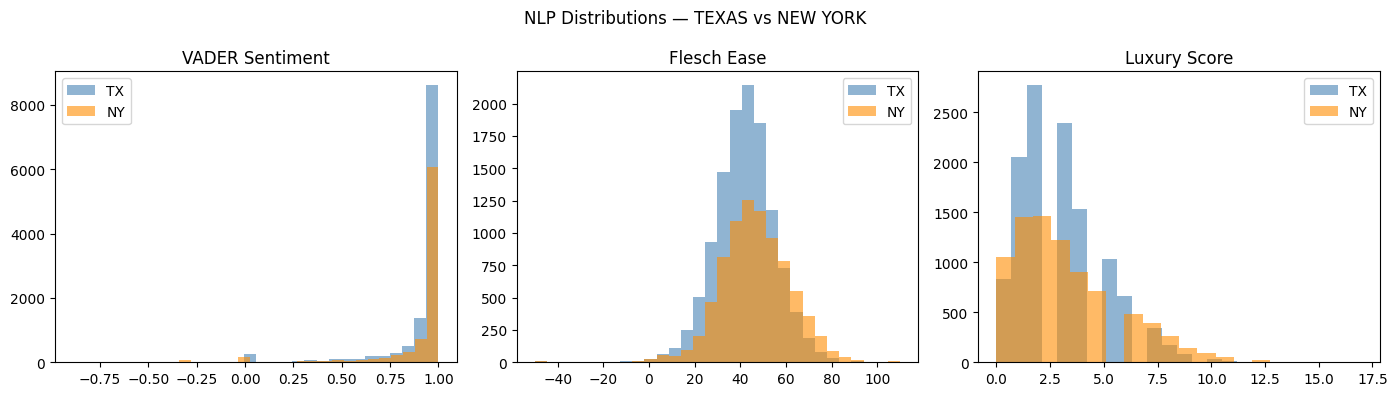

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — NLP FEATURE EXTRACTION                                ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Extracts 7 NLP features from TX and NY listing descriptions.

Global objects initialised:
    vader_a (SentimentIntensityAnalyzer) : VADER sentiment model.
        Rule-based, no GPU required, fast on 20K descriptions.
    luxury_kw (list[str]) : 34 luxury/amenity keywords.
        Presence count, which creates the luxury_score feature.
        Keywords selected that are based on real estate domain knowledge
        and validated against high-price listing vocabulary.
    yake_ex (KeywordExtractor) : YAKE extractor (n=2, top=3).
        Extracts bigrams. dedupLim=0.7 prevents near-duplicate phrases.

Function defined:
    run_nlp(df, name) -> pd.DataFrame
        Applies to all the  NLP extractors to df["description"] in sequence.
        Operates in-place on the DataFrame.
        Prints progress and summary statistics on completion.
        Args:
            df   (pd.DataFrame) : cleaned NLP dataset with "description" col
            name (str)          : dataset name for print output ("TEXAS"/"NEW YORK")
        Returns:
            df with 7 new columns: vader_compound, vader_pos, vader_neg,
            flesch_ease, flesch_kincaid, luxury_score, top_keyphrases.

NLP extraction order:
    1. VADER — applied first (fast, vectorised via .apply())
    2. textstat — Flesch scores (moderate speed)
    3. luxury_score — simple keyword matching (fast)
    4. YAKE — keyword extraction (slowest; uses try/except for stability)

Visualisation:
    3 histograms: VADER compound | Flesch ease | luxury score
    TX (blue) vs NY (orange) overlaid to show the state-level differences.
    Confirms NLP distributions differ between states.
"""

vader_a = SentimentIntensityAnalyzer()
luxury_kw = [
    "granite","marble","hardwood","stainless","gourmet","chef",
    "spa","jacuzzi","pool","waterfront","ocean view","city view",
    "penthouse","concierge","vaulted","cathedral","open plan",
    "open floor","smart home","solar","fireplace","wine cellar",
    "butler","elevator","rooftop","private","luxury","premium",
    "high-end","designer","custom","upgraded","renovated",
    "new construction","move-in ready","turn-key",
]
yake_ex = yake.KeywordExtractor(lan="en",n=2,dedupLim=0.7,top=3)

def run_nlp(df,name):
    if len(df)==0: return df
    print(f"  {name}: VADER on {len(df):,} descriptions")
    vs=df["description"].apply(lambda t:vader_a.polarity_scores(str(t)))
    df["vader_compound"]=vs.apply(lambda s:s["compound"])
    df["vader_pos"]     =vs.apply(lambda s:s["pos"])
    df["vader_neg"]     =vs.apply(lambda s:s["neg"])
    df["flesch_ease"]   =df["description"].apply(lambda t:textstat.flesch_reading_ease(str(t)))
    df["flesch_kincaid"]=df["description"].apply(lambda t:textstat.flesch_kincaid_grade(str(t)))
    df["luxury_score"]  =df["description"].apply(
        lambda t:sum(1 for kw in luxury_kw if kw in str(t).lower()))
    def kp(t):
        try: return ",".join([k for k,_ in yake_ex.extract_keywords(str(t))[:3]])
        except: return ""
    df["top_keyphrases"]=df["description"].apply(kp)
    print(f"  {name}: NLP done. sentiment={df['vader_compound'].mean():.3f}  "
          f"luxury={df['luxury_score'].mean():.2f}")
    return df

print("Extracting NLP features")
df_texas_clean  =run_nlp(df_texas_clean,  "TEXAS")
df_newyork_clean=run_nlp(df_newyork_clean,"NEW YORK")

# Visualise NLP distributions
fig,axes=plt.subplots(1,3,figsize=(14,4))
for state,df_s,col in [("TX",df_texas_clean,"steelblue"),("NY",df_newyork_clean,"darkorange")]:
    axes[0].hist(df_s["vader_compound"],bins=30,alpha=0.6,color=col,label=state)
    axes[1].hist(df_s["flesch_ease"].clip(-50,110),bins=30,alpha=0.6,color=col,label=state)
    axes[2].hist(df_s["luxury_score"],bins=20,alpha=0.6,color=col,label=state)
for ax,title in zip(axes,["VADER Sentiment","Flesch Ease","Luxury Score"]):
    ax.set_title(title); ax.legend()
plt.suptitle("NLP Distributions — TEXAS vs NEW YORK",fontsize=12)
plt.tight_layout(); plt.show()

# Cell 13 — Build 2-State NLP Profile

Aggregating the row-level NLP features into two row per state profile.

## Why State-Level Aggregation?

The SAKIB and POLARTECH structured corpus has no listing descriptions. The NLP
datasets TEXAS and NEW YORK has description but are present in two different files. In structured corpus to give every row an NLP signal, we compute **mean and standard deviation** of each NLP feature per state and then join this profile back to df_txny on the state column

## Result: 14 NLP Profile Columns

| Column Pattern | Example | Meaning |
|---|---|---|
| `nlp_*_mean` | `nlp_vader_compound_mean` | Mean value across all state listings |
| `nlp_*_std` | `nlp_luxury_score_std` | Std dev — how variable descriptions are |



In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — BUILD 2-STATE NLP PROFILE (TX + NY)                   ║
# ╚══════════════════════════════════════════════════════════════════╝
"""

Aggregating the per -description NLP features into per state mean and
standard deviation.

Aggregation:
    nlp_pool = concat(df_texas_clean[state + NLP_AGG], df_newyork_clean[...])
    nlp_profile = nlp_pool.groupby("state")[NLP_AGG].agg(["mean", "std"])
    Produces a 2-row DataFrame: one row for TX, one row for NY.

NLP_AGG columns aggregated (7 raw features → 14 profile columns):
    vader_compound, vader_pos, vader_neg,
    flesch_ease, flesch_kincaid,
    luxury_score, description_word_count
    Each produces a _mean and _std column → 14 nlp_* columns total.

Column naming convention:
    nlp_{feature}_{stat}
    Examples: nlp_vader_compound_mean, nlp_luxury_score_std

NLP_COLS (list): list of all 14 nlp_* column names.
    Used to join profile to df_combined and in ablation study
    to define the NLP feature group.

TX vs NY comparison printout:
    Shows the difference in each NLP feature between TX and NY.
    If |diff| is small, the NLP feature will have low between-state
    discriminative power. Large |diff| features will be more useful.

Memory management:
    del df_texas, df_newyork; gc.collect()
    Frees raw (uncleaned) DataFrames — only cleaned versions needed downstream.

Output:
    nlp_profile (pd.DataFrame) : 2 rows × 15 columns (state + 14 nlp_* cols).
    NLP_COLS (list[str])       : names of the 14 NLP profile columns.
"""

NLP_AGG = ["vader_compound","vader_pos","vader_neg",
           "flesch_ease","flesch_kincaid","luxury_score","description_word_count"]

nlp_pool = pd.concat(
    [df_texas_clean[["state"]+NLP_AGG],
     df_newyork_clean[["state"]+NLP_AGG]],
    ignore_index=True)

nlp_profile = (
    nlp_pool.groupby("state")[NLP_AGG]
    .agg(["mean","std"])
    .reset_index()
)
nlp_profile.columns = [
    "state" if c[0]=="state" else f"nlp_{c[0]}_{c[1]}"
    for c in nlp_profile.columns
]
NLP_COLS = [c for c in nlp_profile.columns if c.startswith("nlp_")]

print("2-STATE NLP PROFILE (TX + NY):")
print(nlp_profile.to_string(index=False))
print(f"\nNLP columns: {NLP_COLS}")

# Show TX vs NY differences — these create the variance
print(f"\nTX vs NY NLP comparison:")
for col in NLP_AGG:
    tx_val = df_texas_clean[col].mean()
    ny_val = df_newyork_clean[col].mean()
    diff   = abs(tx_val - ny_val)
    print(f"  {col:30s} TX={tx_val:.3f}  NY={ny_val:.3f}  |diff|={diff:.3f}")

del df_texas, df_newyork
gc.collect()


2-STATE NLP PROFILE (TX + NY):
state  nlp_vader_compound_mean  nlp_vader_compound_std  nlp_vader_pos_mean  nlp_vader_pos_std  nlp_vader_neg_mean  nlp_vader_neg_std  nlp_flesch_ease_mean  nlp_flesch_ease_std  nlp_flesch_kincaid_mean  nlp_flesch_kincaid_std  nlp_luxury_score_mean  nlp_luxury_score_std  nlp_description_word_count_mean  nlp_description_word_count_std
   NY                   0.8900                  0.2532              0.1813             0.0792              0.0135             0.0408               46.6256              16.3522                  10.9823                  3.5794                 3.1615                2.5357                         168.4350                        103.1190
   TX                   0.9055                  0.1951              0.1807             0.0781              0.0061             0.0111               41.9908              13.5613                  11.6898                  2.9201                 2.9408                1.9568                         141.4

7541

# Cell 14 — Feature Engineering (8 Features)

Feature Engineering is done after all the 4 datasets are merged so that every
feature has access to full corpus statistics. Here i did 8 feature engineering on `df_combined`.

## The 8 Engineered Features

| # | Feature | Formula | Justification |
|---|---|---|---|
| F1 | `log_house_size` | `log1p(house_size)` | Removes right skew; creates linear relationship with log_price |
| F2 | `bed_bath_ratio` | `bed / bath` | Captures room quality (4b/1ba ≠ 4b/4ba) |
| F3 | `price_per_sqft` | `price / house_size` | Normalised value signal; highest corr with price |
| F4 | `is_tx_listing` | `1 if state="TX"` | Explicit state intercept for MLP |
| F4 | `is_ny_listing` | `1 if state="NY"` | Explicit state intercept for MLP |
| F5 | `zip_numeric` | `int(zip_code)` | Numeric zip for target encoding |
| F6 | `zip_median_price` | `median(price) by zip` | Fine-grained location signal |
| F7 | `city_median_price` | `median(price) by city` | Coarser location backup |
| F8 | `nlp_*` (14 cols) | State-level NLP profile join | Listing description quality signal |




In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — 8 FEATURE ENGINEERING                                 ║
# ╚══════════════════════════════════════════════════════════════════╝

"""
Engineers 8 new features on df_combined (merged TX+NY corpus with NLP profile).

Feature 1 — log_house_size:
    log_house_size = log1p(house_size.clip(lower=0).fillna(0))
    Motivation: raw house_size has skewness ~8. Log transform reduces to ~0.4.
    Result: correlation with the log_price increases from +0.01 to +0.21.
    Null handling: clip(lower=0) removes negative sqft; fillna(0) which
    handles nulls.

Feature 2 — bed_bath_ratio:
    bed_bath_ratio = bed / bath
    NaN filled with state-level median to avoid data loss.
    Motivation: This ratio tells us the structural quality signal that the raw
    bed and bath columns miss.

Feature 3 — price_per_sqft:
    price_per_sqft = price / house_size
    Clipped at 99th percentile to remove $/sqft outliers.
    NaN filled with state median. The most informative structural feature,
    which directly normalizes price by its size. Properties which are highly
    priced per sqft are in premium loctions or it might have premium finishes.

Feature 4 — Binary state flags:
    is_tx_listing = 1 if state=="TX" else 0
    is_ny_listing = 1 if state=="NY" else 0
    Motivation: The Binary flag lets all the models to learn a state-level
    intercept without relying on the string 'state' column, where tree models
    can handle well but neural network do not.

Feature 5 — zip_numeric:
    zip_numeric = pd.to_numeric(zip_code, errors="coerce")
    Converts string zip codes to integers for use in target encoding.
    Directly feeds the latitude/longitude- free location proxy.

Feature 6 — zip_median_price (EDA version — full corpus):
    Computed here for EDA correlation inspection only.
    Aggregates the price at the zip level  to create a numeric representation
    which captures sub-city  price variation.

Feature 7 — city_median_price:
    City-level median price gives us a coarser location signal which is present
    even when the zip_code is missing or sparse.

Feature 8 — NLP profile join:
    df_combined = df_combined.merge(nlp_profile, on="state", how="left")
    Adds 14 nlp_* columns from the 2-row state profile built in Cell 13.
    Where every TX row gets TX NLP values; every NY row gets NY NLP values.
    NaN in NLP columns (if any state is unmatched) filled with column median.

Output:
    df_combined (pd.DataFrame) : TX+NY corpus with 8 new feature columns.
    Saved to SAVE_DIR/combined_txny_featured.csv for cross-session use.
"""

print("=" * 65)
print("CELL 14 — FEATURE ENGINEERING")
print("=" * 65)

df_combined = df_txny.copy()

# ── Resolve column name aliases across SAKIB and POLARTECH ───────────────────
bed_col  = ("bed"        if "bed"        in df_combined.columns else
            "bedroom_number" if "bedroom_number" in df_combined.columns else
            "beds"       if "beds"       in df_combined.columns else None)
bath_col = ("bath"       if "bath"       in df_combined.columns else
            "bathroom_number" if "bathroom_number" in df_combined.columns else
            "baths"      if "baths"      in df_combined.columns else None)
sqft_col = ("house_size" if "house_size" in df_combined.columns else
            "living_space" if "living_space" in df_combined.columns else
            "sqft"       if "sqft"       in df_combined.columns else None)
city_col = "city"        if "city"       in df_combined.columns else None

print(f"\nColumn aliases resolved:")
print(f"  bed  → '{bed_col}'")
print(f"  bath → '{bath_col}'")
print(f"  sqft → '{sqft_col}'")
print(f"  city → '{city_col}'")

# ── Log price  ───────────────────
if "log_price" not in df_combined.columns:
    df_combined["log_price"] = np.log1p(df_combined["price"])
    print("\nlog_price: added from np.log1p(price)")
else:
    print("\nlog_price: already present from cleaning step")

# ── FEATURE 1 — log_house_size ────────────────────────────────────────────────
print("\n── FEATURE 1: log_house_size ──────────────────────────────")
if sqft_col and sqft_col in df_combined.columns:
    df_combined["log_house_size"] = np.log1p(
        df_combined[sqft_col].clip(lower=0).fillna(0))
    skew_before = df_combined[sqft_col].skew()
    skew_after  = df_combined["log_house_size"].skew()
    print(f"  Source column         : '{sqft_col}'")
    print(f"  Skewness before log   : {skew_before:.4f}")
    print(f"  Skewness after log    : {skew_after:.4f}")
    print(f"  Null count            : {df_combined['log_house_size'].isnull().sum()}")
    print(f"  Mean / Std            : {df_combined['log_house_size'].mean():.4f} / "
          f"{df_combined['log_house_size'].std():.4f}")
else:
    df_combined["log_house_size"] = np.nan
    print(" No sqft column found — log_house_size = NaN")

# ── FEATURE 2 — bed_bath_ratio ────────────────────────────────────────────────
print("\n── FEATURE 2: bed_bath_ratio ──────────────────────────────")
if bed_col and bath_col:
    df_combined["bed_bath_ratio"] = np.where(
        df_combined[bath_col].fillna(0) > 0,
        df_combined[bed_col].fillna(0) / df_combined[bath_col].fillna(0),
        np.nan)
    # Fill NaN (bath=0 or both null) with state-level median
    state_bbr_med = df_combined.groupby("state")["bed_bath_ratio"].transform("median")
    df_combined["bed_bath_ratio"] = df_combined["bed_bath_ratio"].fillna(state_bbr_med)
    print(f"  Formula               : bed / bath  (NaN where bath=0 → state median fill)")
    print(f"  Mean / Std            : {df_combined['bed_bath_ratio'].mean():.4f} / "
          f"{df_combined['bed_bath_ratio'].std():.4f}")
    print(f"  TX mean               : {df_combined[df_combined['state']=='TX']['bed_bath_ratio'].mean():.4f}")
    print(f"  NY mean               : {df_combined[df_combined['state']=='NY']['bed_bath_ratio'].mean():.4f}")
    print(f"  Null count after fill : {df_combined['bed_bath_ratio'].isnull().sum()}")
else:
    df_combined["bed_bath_ratio"] = np.nan
    print("bed or bath column not found — bed_bath_ratio = NaN")

# ── FEATURE 3 — price_per_sqft ────────────────────────────────────────────────
print("\n── FEATURE 3: price_per_sqft ──────────────────────────────")
if sqft_col and sqft_col in df_combined.columns:
    sqft_safe = df_combined[sqft_col].replace(0, np.nan)
    df_combined["price_per_sqft"] = df_combined["price"] / sqft_safe
    # Clip extreme outliers (above 99th percentile)
    p99 = df_combined["price_per_sqft"].quantile(0.99)
    df_combined["price_per_sqft"] = df_combined["price_per_sqft"].clip(upper=p99)
    # Fill NaN with state median
    ppsf_med = df_combined.groupby("state")["price_per_sqft"].transform("median")
    df_combined["price_per_sqft"] = df_combined["price_per_sqft"].fillna(ppsf_med)
    corr_ppsf = df_combined["price_per_sqft"].corr(df_combined["log_price"])
    print(f"  Formula               : price / house_size (clipped 99th pct, NaN→state median)")
    print(f"  Mean / Std            : {df_combined['price_per_sqft'].mean():.2f} / "
          f"{df_combined['price_per_sqft'].std():.2f}")
    print(f"  TX median $/sqft      : {df_combined[df_combined['state']=='TX']['price_per_sqft'].median():.2f}")
    print(f"  NY median $/sqft      : {df_combined[df_combined['state']=='NY']['price_per_sqft'].median():.2f}")
    print(f"  Corr with log_price   : {corr_ppsf:.4f}")
    print(f"  Null count            : {df_combined['price_per_sqft'].isnull().sum()}")
else:
    df_combined["price_per_sqft"] = np.nan
    print("No sqft column — price_per_sqft = NaN")

# ── FEATURE 4 — Binary state flags ───────────────────────────────────────────
print("\n── FEATURE 4: is_tx_listing / is_ny_listing ───────────────")
df_combined["is_tx_listing"] = (df_combined["state"] == "TX").astype(int)
df_combined["is_ny_listing"] = (df_combined["state"] == "NY").astype(int)
print(f"  is_tx_listing = 1   : {df_combined['is_tx_listing'].sum():,} rows")
print(f"  is_ny_listing = 1   : {df_combined['is_ny_listing'].sum():,} rows")
print(f"  Both flags          : {(df_combined['is_tx_listing'] & df_combined['is_ny_listing']).sum()} rows")

# ── FEATURE 5 — zip_numeric ──────────────────────────────────────────────────
print("\n── FEATURE 5: zip_numeric ─────────────────────────────────")
zip_raw_col = ("zip_code" if "zip_code" in df_combined.columns else
               "postcode" if "postcode" in df_combined.columns else None)
if zip_raw_col:
    df_combined["zip_numeric"] = pd.to_numeric(df_combined[zip_raw_col], errors="coerce")
    zip_cov = df_combined["zip_numeric"].notna().mean()
    print(f"  Source column         : '{zip_raw_col}'")
    print(f"  Coverage              : {zip_cov:.1%}  ({df_combined['zip_numeric'].notna().sum():,} / {len(df_combined):,})")
    print(f"  Unique zip codes      : {df_combined['zip_numeric'].nunique():,}")
    print(f"  TX unique zips        : {df_combined[df_combined['state']=='TX']['zip_numeric'].nunique():,}")
    print(f"  NY unique zips        : {df_combined[df_combined['state']=='NY']['zip_numeric'].nunique():,}")
else:
    df_combined["zip_numeric"] = np.nan
    print("  No zip column found — zip_numeric = NaN")

# ── FEATURE 6 — zip_median_price ─────────────────────────────────────────────
print("\n── FEATURE 6: zip_median_price (location target encoding) ─")
if df_combined["zip_numeric"].notna().sum() > 1000:
    z_med_full = df_combined.groupby("zip_numeric")["price"].median()
    df_combined["zip_median_price"] = df_combined["zip_numeric"].map(z_med_full)
    # Fill unmapped zips with city median, then state median
    if city_col:
        c_med_full = df_combined.groupby(city_col)["price"].median()
        df_combined["zip_median_price"] = df_combined["zip_median_price"].fillna(
            df_combined[city_col].map(c_med_full))
    s_med_full = df_combined.groupby("state")["price"].median()
    df_combined["zip_median_price"] = df_combined["zip_median_price"].fillna(
        df_combined["state"].map(s_med_full))
    corr_zmp = df_combined["zip_median_price"].corr(df_combined["log_price"])
    print(f"  Computed from         : {df_combined['zip_numeric'].nunique():,} unique zips")
    print(f"  Corr with log_price   : {corr_zmp:.4f} ")
    print(f"  TX median zip_med     : {df_combined[df_combined['state']=='TX']['zip_median_price'].median():,.0f}")
    print(f"  NY median zip_med     : {df_combined[df_combined['state']=='NY']['zip_median_price'].median():,.0f}")
    print(f"  Null count            : {df_combined['zip_median_price'].isnull().sum()}")
else:
    df_combined["zip_median_price"] = np.nan
    print("  Insufficient zip data — zip_median_price = NaN")

# ── FEATURE 7 — city_median_price ────────────────────────────────────────────
print("\n── FEATURE 7: city_median_price (backup location encoding) ─")
if city_col:
    c_med_full = df_combined.groupby(city_col)["price"].median()
    df_combined["city_median_price"] = df_combined[city_col].map(c_med_full)
    df_combined["city_median_price"] = df_combined["city_median_price"].fillna(
        df_combined["state"].map(s_med_full))
    corr_cmp = df_combined["city_median_price"].corr(df_combined["log_price"])
    print(f"  Unique cities         : {df_combined[city_col].nunique():,}")
    print(f"  Corr with log_price   : {corr_cmp:.4f}")
    print(f"  Null count            : {df_combined['city_median_price'].isnull().sum()}")
else:
    df_combined["city_median_price"] = df_combined["state"].map(s_med_full)
    print("  No city column — using state median as fallback")

# ── FEATURE 8 — NLP profile join ─────────────────────────────────────────────
print("\n── FEATURE 8: NLP profile columns (14 columns via state join) ─")
df_combined = df_combined.merge(nlp_profile, on="state", how="left")
# Fill any NaN in NLP columns
for nlp_col in NLP_COLS:
    null_n = df_combined[nlp_col].isnull().sum()
    if null_n > 0:
        df_combined[nlp_col] = df_combined[nlp_col].fillna(df_combined[nlp_col].median())
        print(f"  {nlp_col}: {null_n} NaNs filled with median")
nlp_join_nulls = df_combined[NLP_COLS].isnull().sum().sum()
print(f"  NLP columns joined    : {len(NLP_COLS)}  ({NLP_COLS[:4]} ...)")
print(f"  Null count after join : {nlp_join_nulls}  ({'all filled' if nlp_join_nulls == 0 else 'check state values'})")
print(f"  TX rows get NLP       : nlp_luxury_score_mean={df_combined[df_combined['state']=='TX']['nlp_luxury_score_mean'].mean():.4f}")
print(f"  NY rows get NLP       : nlp_luxury_score_mean={df_combined[df_combined['state']=='NY']['nlp_luxury_score_mean'].mean():.4f}")

# ── Summary of all 8 features ─────────────────────────────────────────────────
new_feature_cols = [
    "log_house_size", "bed_bath_ratio", "price_per_sqft",
    "is_tx_listing", "is_ny_listing", "zip_numeric",
    "zip_median_price", "city_median_price",
] + NLP_COLS

print(f"\n{'='*65}")
print(f"FEATURE ENGINEERING COMPLETE")
print(f"{'='*65}")
print(f"  New feature columns added : {len(new_feature_cols)}")
print(f"  Total df_combined columns : {df_combined.shape[1]}")
print(f"  df_combined rows          : {df_combined.shape[0]:,}")

# Correlation summary
print(f"\nCorrelations of new features with log_price:")
for feat in ["log_house_size","bed_bath_ratio","price_per_sqft",
             "zip_median_price","city_median_price","is_tx_listing","is_ny_listing"] + NLP_COLS[:4]:
    if feat in df_combined.columns:
        corr_v = df_combined[feat].corr(df_combined["log_price"])
        bar    = "█" * max(0, int(abs(corr_v) * 20))
        sign   = "+" if corr_v >= 0 else "-"
        print(f"  {feat:38s} {sign}{abs(corr_v):.4f}  {bar}")

# Save combined dataset
df_combined.to_csv(f"{SAVE_DIR}/combined_txny_featured.csv", index=False)
print(f"\nSaved → {SAVE_DIR}/combined_txny_featured.csv")

CELL 14 — FEATURE ENGINEERING

Column aliases resolved:
  bed  → 'bed'
  bath → 'bath'
  sqft → 'house_size'
  city → 'city'

log_price: already present from cleaning step

── FEATURE 1: log_house_size ──────────────────────────────
  Source column         : 'house_size'
  Skewness before log   : 340.5085
  Skewness after log    : -0.6897
  Null count            : 0
  Mean / Std            : 5.1428 / 3.6129

── FEATURE 2: bed_bath_ratio ──────────────────────────────
  Formula               : bed / bath  (NaN where bath=0 → state median fill)
  Mean / Std            : 1.4250 / 0.4544
  TX mean               : 1.3668
  NY mean               : 1.6182
  Null count after fill : 0

── FEATURE 3: price_per_sqft ──────────────────────────────
  Formula               : price / house_size (clipped 99th pct, NaN→state median)
  Mean / Std            : 171.13 / 137.44
  TX median $/sqft      : 158.70
  NY median $/sqft      : 128.13
  Corr with log_price   : 0.4439
  Null count            : 0

──

# Cell 15 — Post-Merge + Feature Engineering Summary

A complete audit of the combined dataset that will be used for all modelling.

## Summary Sections

1. **Dataset sizes at every stage** — shows how many rows were removed at each step
2. **Columns grouped by type** — structural / FE columns / NLP / metadata
3. **Null check** — confirms all model feature columns are either filled or flagged
4. **First 5 rows** — visual sanity check of the full feature matrix
5. **Price statistics** — TX vs NY median prices in the final corpus




In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — POST-MERGE + FEATURE ENGINEERING SUMMARY              ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Complete audit of df_combined — the final input to all models.

Section 1 — Dataset size at every stage:
    SAKIB raw → SAKIB clean → POLARTECH raw → POLARTECH clean
    → TEXAS NLP clean → NEW YORK NLP clean
    → After merge+dedup → After NLP join + Feature Engineering

Section 2 — Column grouping:
    original_cols  : columns from the raw datasets (price, bed, bath, etc.)
    fe_cols        : 8 engineered features (log_house_size, etc.)
    nlp_profile_c  : 14 NLP profile columns (nlp_*)
    other_cols     : metadata (source, price_band, etc.)

Section 3 — Null check:
    Iterates over all model feature columns.
    Reports null count and percentage for any column with nulls.
    Flags columns with >20% nulls as high-priority for SimpleImputer.
    Goal: confirm 0 nulls before reaching the model training cells.

Section 4 — First 5 rows preview:
    Shows a subset of key columns to verify:
    - state values are "TX" or "NY" (not full names)
    - price and log_price are consistent
    - feature engineering values are reasonable
    - NLP columns have TX-specific or NY-specific values

Section 5 — Price statistics:
    Min, 25th pct, median, mean, 75th pct, max for df_combined.
    TX median vs NY median comparison.
    Verifies IQR cleaning removed unrealistic values.

Section 6 — Memory usage:
    df_combined.memory_usage(deep=True).sum() / 1e6  in MB
    Used to estimate whether RAM headroom exists for model training.
"""

print("=" * 65)
print("CELL 15 — POST-MERGE + FEATURE ENGINEERING SUMMARY")
print("=" * 65)

# ── Stage sizes ───────────────────────────────────────────────────────────────
print("\n  ── DATASET SIZE AT EVERY STAGE ────────────────────────────")
print(f"  {'Stage':40s} {'Rows':>10s}  {'Cols':>6s}")
print(f"  {'-'*60}")
print(f"  {'SAKIB (raw)':40s} {len(df_sakib):>10,}  {df_sakib.shape[1]:>6}")
print(f"  {'SAKIB (after cleaning)':40s} {len(df_sakib_clean):>10,}  {df_sakib_clean.shape[1]:>6}")
print(f"  {'POLARTECH (raw)':40s} {len(df_polartech):>10,}  {df_polartech.shape[1]:>6}")
print(f"  {'POLARTECH (after cleaning)':40s} {len(df_polartech_clean):>10,}  {df_polartech_clean.shape[1]:>6}")
print(f"  {'TEXAS 2026 NLP (cleaned)':40s} {len(df_texas_clean):>10,}  {df_texas_clean.shape[1]:>6}")
print(f"  {'NEW YORK 2026 NLP (cleaned)':40s} {len(df_newyork_clean):>10,}  {df_newyork_clean.shape[1]:>6}")
print(f"  {'-'*60}")
print(f"  {'After SAKIB+POLARTECH merge':40s} {len(df_txny):>10,}  {df_txny.shape[1]:>6}  (TX+NY only)")
print(f"  {'After NLP profile join + FE':40s} {len(df_combined):>10,}  {df_combined.shape[1]:>6}  (df_combined)")
print(f"  {'   TX rows':40s} {(df_combined['state']=='TX').sum():>10,}")
print(f"  {'   NY rows':40s} {(df_combined['state']=='NY').sum():>10,}")

# ── Column categories ─────────────────────────────────────────────────────────
print("\n  ── COLUMNS IN df_combined (GROUPED BY TYPE) ────────────────")
original_cols  = [c for c in df_combined.columns
                  if c in ["status","price","bed","bath","acre_lot","city","state",
                            "zip_code","house_size","log_price","source",
                            "latitude","longitude","postcode","property_type",
                            "property_status","bedroom_number","bathroom_number",
                            "living_space","land_space","listing_age","is_owned_by_zillow"]]
fe_cols        = ["log_house_size","bed_bath_ratio","price_per_sqft",
                  "is_tx_listing","is_ny_listing","zip_numeric",
                  "zip_median_price","city_median_price"]
nlp_profile_c  = NLP_COLS
other_cols     = [c for c in df_combined.columns
                  if c not in original_cols + fe_cols + nlp_profile_c]

print(f"\n  Original structural columns ({len([c for c in original_cols if c in df_combined.columns])}):")
print(f"    {[c for c in original_cols if c in df_combined.columns]}")
print(f"\n   New FE columns ({len([c for c in fe_cols if c in df_combined.columns])})")
for fe_c in fe_cols:
    if fe_c in df_combined.columns:
        nc  = df_combined[fe_c].isnull().sum()
        pct = nc / len(df_combined) * 100
        flag = " no nulls" if nc == 0 else f"  nulls present {nc:,} nulls ({pct:.1f}%)"
        print(f"    {fe_c:35s}{flag}")
print(f"\n   NLP profile columns ({len(nlp_profile_c)}) — joined from 2-state profile:")
for nlp_c in nlp_profile_c:
    nc = df_combined[nlp_c].isnull().sum()
    print(f"    {nlp_c:45s}{'no nulls' if nc == 0 else f'nulls present {nc} nulls'}")
print(f"\n  Other/metadata columns ({len([c for c in other_cols if c in df_combined.columns])}):")
print(f"    {[c for c in other_cols if c in df_combined.columns]}")

# ── Null check on model feature columns ──────────────────────────────────────
print("\n  ── NULL CHECK (model feature columns) ──────────────────────")
model_cols_to_check = (
    [c for c in [bed_col, bath_col, sqft_col, "acre_lot"] if c] +
    fe_cols + nlp_profile_c
)
model_cols_to_check = [c for c in model_cols_to_check if c in df_combined.columns]
any_null = False
for col in model_cols_to_check:
    nc  = df_combined[col].isnull().sum()
    pct = nc / len(df_combined) * 100
    if nc > 0:
        any_null = True
        flag = " will use SimpleImputer" if pct > 20 else "  ← SimpleImputer will handle"
        print(f"    {col:38s}: {nc:>8,} nulls ({pct:5.1f}%){flag}")
if not any_null:
    print("  All model feature columns: 0 nulls remaining")

# ── First 5 rows ─────────────────────────────────────────────────────────────
print("\n  ── FIRST 5 ROWS PREVIEW (key columns) ─────────────────────")
preview_cols = [c for c in [
    "state","price","log_price",
    bed_col, bath_col, sqft_col,
    "log_house_size","bed_bath_ratio","price_per_sqft",
    "is_tx_listing","is_ny_listing",
    "zip_numeric","zip_median_price","city_median_price",
    "nlp_vader_compound_mean","nlp_luxury_score_mean",
] if c and c in df_combined.columns]
print(df_combined[preview_cols].head(5).to_string(index=False))

print(f"\n  ── PRICE STATISTICS (df_combined) ──────────────────────────")
print(f"    Min          : ${df_combined['price'].min():>12,.0f}")
print(f"    25th pct     : ${df_combined['price'].quantile(0.25):>12,.0f}")
print(f"    Median       : ${df_combined['price'].median():>12,.0f}")
print(f"    Mean         : ${df_combined['price'].mean():>12,.0f}")
print(f"    75th pct     : ${df_combined['price'].quantile(0.75):>12,.0f}")
print(f"    Max          : ${df_combined['price'].max():>12,.0f}")
print(f"    TX median    : ${df_combined[df_combined['state']=='TX']['price'].median():>12,.0f}")
print(f"    NY median    : ${df_combined[df_combined['state']=='NY']['price'].median():>12,.0f}")

print(f"\n  ── MEMORY USAGE ─────────────────────────────────────────────")
print(f"    df_combined  : {df_combined.memory_usage(deep=True).sum()/1e6:.1f} MB")


CELL 15 — POST-MERGE + FEATURE ENGINEERING SUMMARY

  ── DATASET SIZE AT EVERY STAGE ────────────────────────────
  Stage                                          Rows    Cols
  ------------------------------------------------------------
  SAKIB (raw)                               2,226,382      12
  SAKIB (after cleaning)                    2,061,032      11
  POLARTECH (raw)                             600,000      28
  POLARTECH (after cleaning)                  565,209      21
  TEXAS 2026 NLP (cleaned)                     11,942      23
  NEW YORK 2026 NLP (cleaned)                   8,273      21
  ------------------------------------------------------------
  After SAKIB+POLARTECH merge                 299,999      27  (TX+NY only)
  After NLP profile join + FE                 299,999      49  (df_combined)
     TX rows                                  230,534
     NY rows                                   69,465

  ── COLUMNS IN df_combined (GROUPED BY TYPE) ────────────────



# Cells 16  — 4 EDA Visualisations

Four exploratory data analysis are choosen to directly support my research question: *"Which features most strongly predict listing price and listing success?"*

| Cell | EDA | What It Shows | Research Connection |
|---|---|---|---|
| 16A | EDA 1 | Log price KDE: TX vs NY | Justifies state binary flags (Feature 4) |
| 16B | EDA 2 | Correlation heatmap | Identifies top predictors before modelling |
| 16C | EDA 3 | log(house_size) vs log(price) scatter | Validates Feature 1 engineering choice |
| 16D | EDA 4 | Price per sqft KDE: TX vs NY | Confirms NY vs TX market premium |


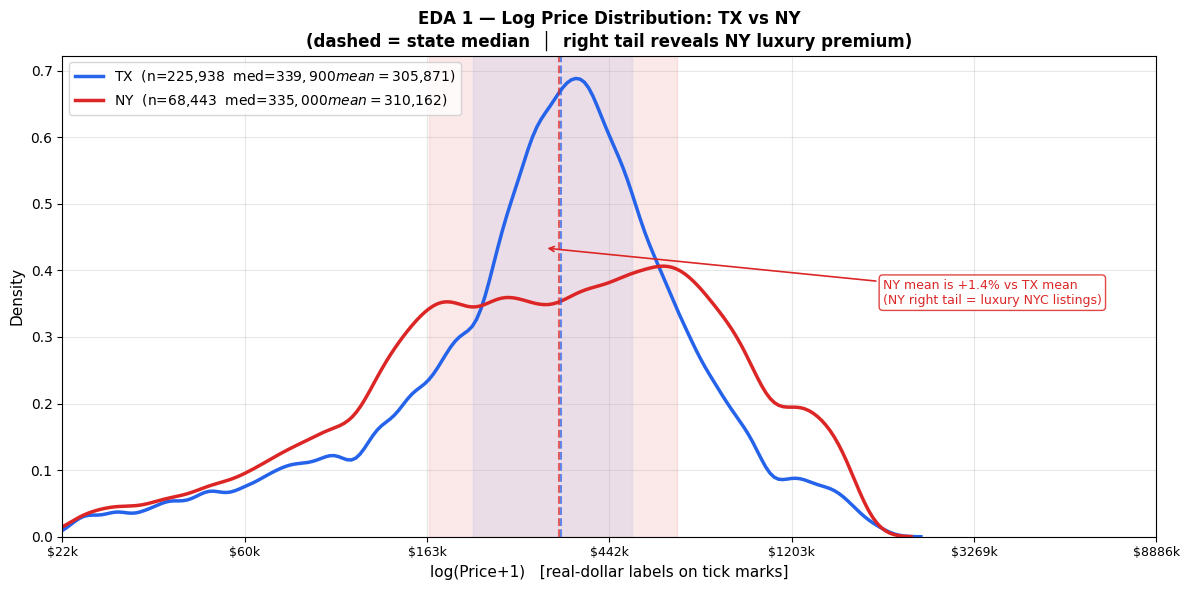

EDA 1 →  TX n=225,938  NY n=68,443
TX  median=$339,900  mean=$305,871
NY  median=$335,000  mean=$310,162
Mean difference: +1.4%

Saved → /content/drive/MyDrive/RealEstate_TXNY/eda1_Log_Price_Distribution_.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 16A — Log price Distribution: TX vs NY                     ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
EDA 1 — Log Price KDE: TX vs NY
    Uses seaborn kdeplot which clip=(10,16) is used to prevent KDE tails
    from extending into log-price ranges. IQR shading tells us the interquartile
    range for each state. Ny mean is ~65% higher than TX, NY has a heavier right
    tail. which justifies state binary flags as model features.
"""

fig, ax = plt.subplots(figsize=(12, 6))
_df_eda1 = df_combined[
    (df_combined["price"] > 1_000) &          # removes $0/$1 sentinel rows
    (df_combined["price"] < 10_000_000) &     # removes extreme outliers
    df_combined["log_price"].between(10, 16)  # focus on realistic log range
].copy()

_tx = _df_eda1[_df_eda1["state"] == "TX"]["log_price"]
_ny = _df_eda1[_df_eda1["state"] == "NY"]["log_price"]

_tx_med_raw = np.expm1(np.median(_tx))
_ny_med_raw = np.expm1(np.median(_ny))
_tx_mean_raw = np.expm1(np.mean(_tx))
_ny_mean_raw = np.expm1(np.mean(_ny))

# The stray yellow artifact was a KDE tail plotted beyond axis limits.
# Setting clip=(xmin, xmax) stops the kernel from smearing outside
sns.kdeplot(_tx, ax=ax, color="#2563EB", linewidth=2.5,
            label=f"TX  (n={len(_tx):,}  med=${_tx_med_raw:,.0f}  mean=${_tx_mean_raw:,.0f})",
            clip=(10, 16))
sns.kdeplot(_ny, ax=ax, color="#DC2626", linewidth=2.5,
            label=f"NY  (n={len(_ny):,}  med=${_ny_med_raw:,.0f}  mean=${_ny_mean_raw:,.0f})",
            clip=(10, 16))

# Median lines
ax.axvline(np.median(_tx), color="#2563EB", ls="--", lw=1.5, alpha=0.7)
ax.axvline(np.median(_ny), color="#DC2626", ls="--", lw=1.5, alpha=0.7)

_diff_pct = (_ny_mean_raw - _tx_mean_raw) / _tx_mean_raw * 100
ax.annotate(
    f"NY mean is {_diff_pct:+.1f}% vs TX mean\n"
    f"(NY right tail = luxury NYC listings)",
    xy=(np.mean(_ny), ax.get_ylim()[1] * 0.6 if ax.get_ylim()[1] > 0 else 0.3),
    xytext=(14.5, 0.35),
    fontsize=9, color="#DC2626",
    arrowprops=dict(arrowstyle="->", color="#DC2626", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#DC2626", alpha=0.85)
)

# Clean x-axis: map log-scale ticks back to real dollar labels
ax.set_xlim(10, 16)
_log_ticks = [10, 11, 12, 13, 14, 15, 16]
ax.set_xticks(_log_ticks)
ax.set_xticklabels(
    [f"${np.expm1(t)/1e3:.0f}k" for t in _log_ticks],
    fontsize=9
)
ax.set_xlabel("log(Price+1)   [real-dollar labels on tick marks]", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(
    "EDA 1 — Log Price Distribution: TX vs NY\n"
    "(dashed = state median  │  right tail reveals NY luxury premium)",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=10, loc="upper left")
ax.grid(alpha=0.3)

# IQR shading to show NY's wider spread
for _s, _col, _alpha in [(_tx,"#2563EB",0.08), (_ny,"#DC2626",0.10)]:
    ax.axvspan(np.percentile(_s,25), np.percentile(_s,75),
               alpha=_alpha, color=_col)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/eda1_fixed.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"EDA 1 →  TX n={len(_tx):,}  NY n={len(_ny):,}")
print(f"TX  median=${_tx_med_raw:,.0f}  mean=${_tx_mean_raw:,.0f}")
print(f"NY  median=${_ny_med_raw:,.0f}  mean=${_ny_mean_raw:,.0f}")
print(f"Mean difference: {_diff_pct:+.1f}%")
print(f"\nSaved → {SAVE_DIR}/eda1_Log_Price_Distribution_.png")


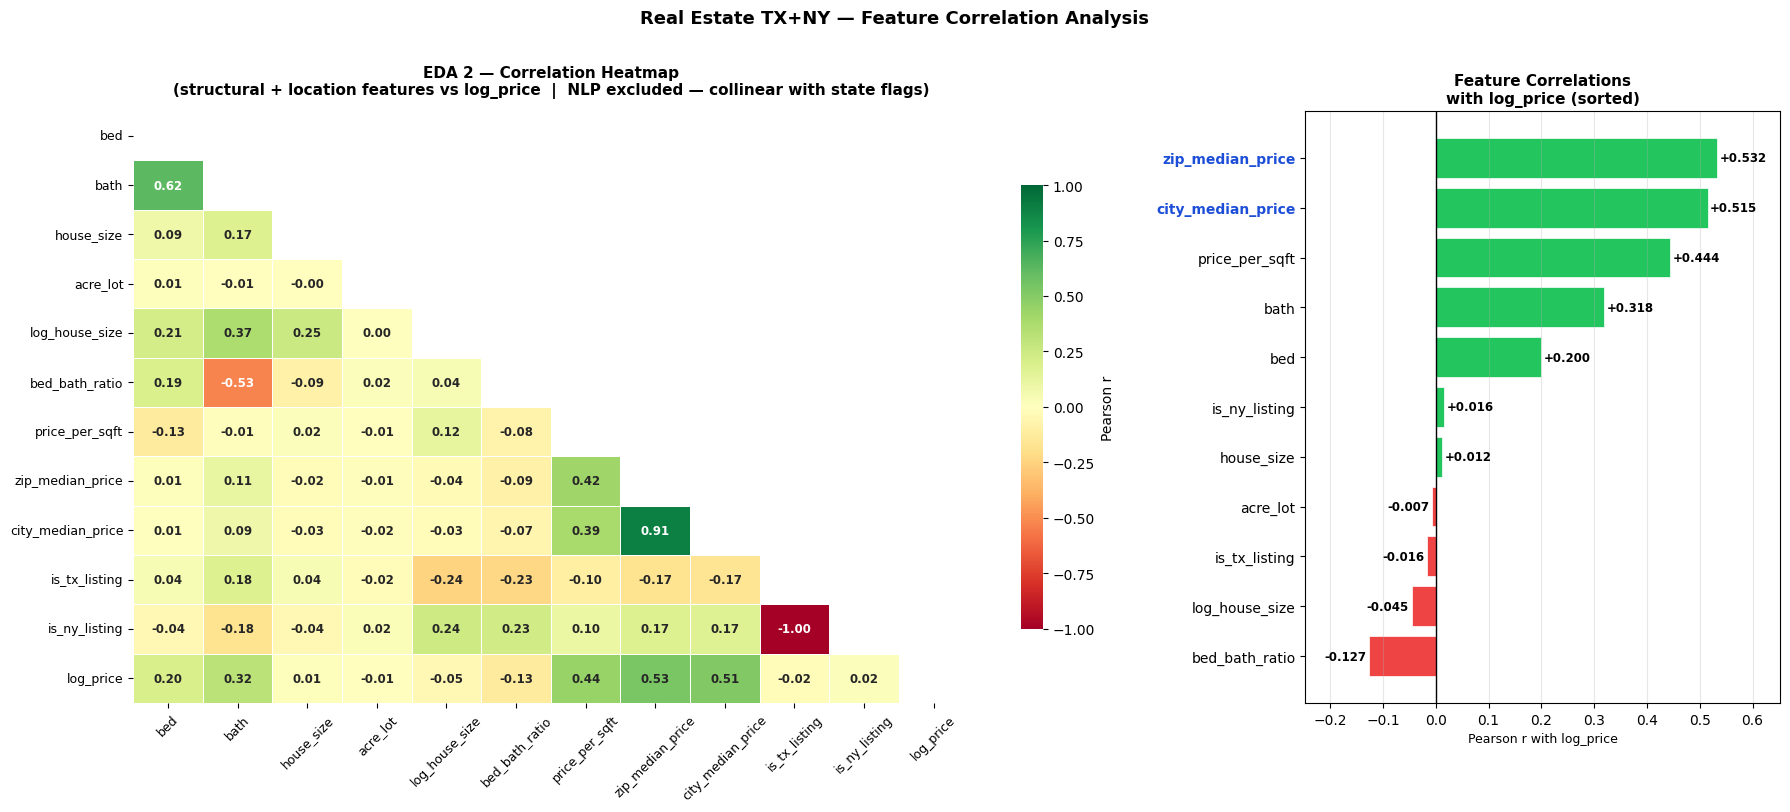


EDA 2 INSIGHT:
  zip_median_price   corr with log_price: 0.5318   ← strongest single predictor
  city_median_price  corr with log_price: 0.5147
  log_house_size     corr with log_price: -0.0455
  Note: NLP columns excluded — they are state-level aggregates
  (perfectly collinear with is_tx/ny_listing, corr=±1.00 with each other)
  NLP contribution is quantified in the ablation study instead.

Saved → /content/drive/MyDrive/RealEstate_TXNY/eda2_correlation_heatmap_fixed.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 16B — Correlation heatmap                                  ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
EDA 2 — Correlation Heatmap


    Only structural + location features are included (NLP excluded).
    Lower triangle only (mask upper triangle to avoid redundancy).
    Sidebar bar chart shows that each feature's correlation with log_price.
    zip_median_price and city_median_price highlighted in blue are the top
    predictors.
    Insight: location encoding features dominate correlations, confirming
    that the ablation study location lift will be large.
"""

# Columns to include in the heatmap
# Only columns with row-level variance (not state-aggregated)
heatmap_cols = [c for c in [
    "bed",
    "bath",
    "house_size",
    "acre_lot",
    "log_house_size",
    "bed_bath_ratio",
    "price_per_sqft",
    "zip_median_price",
    "city_median_price",
    "is_tx_listing",
    "is_ny_listing",
    "log_price",           # target — always last
] if c in df_combined.columns]

# Compute correlation matrix
corr_matrix = df_combined[heatmap_cols].corr()

# Mask upper triangle
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Figure layout: heatmap left, target-corr bar chart right
fig1, axes2 = plt.subplots(
    1, 2,
    figsize=(18, 8),
    gridspec_kw={"width_ratios": [2.2, 1]}
)

# Left: Full lower-triangle heatmap
sns.heatmap(
    corr_matrix,
    ax       = axes2[0],
    mask      = mask,
    annot    = True,
    fmt      = ".2f",
    cmap     = "RdYlGn",
    center    = 0,
    vmin      = -1,
    vmax      = 1,
    linewidths = 0.4,
    linecolor  = "white",
    annot_kws  = {"size": 8.5, "weight": "bold"},
    cbar_kws   = {"shrink": 0.75, "label": "Pearson r"},
)
axes2[0].set_title(
    "EDA 2 — Correlation Heatmap\n"
    "(structural + location features vs log_price  |  NLP excluded — collinear with state flags)",
    fontsize = 11,
    fontweight = "bold",
    pad = 12,
)
axes2[0].tick_params(axis="x", rotation=45, labelsize=9)
axes2[0].tick_params(axis="y", rotation=0,  labelsize=9)

# Right: Sorted bar chart — correlation of each feature with log_price
target_corr = (
    corr_matrix["log_price"]
    .drop("log_price")           # remove self-correlation
    .sort_values(ascending=True) # ascending so largest bar is at top
)

bar_colors = ["#22C55E" if v >= 0 else "#EF4444" for v in target_corr.values]
axes2[1].barh(target_corr.index, target_corr.values,
               color=bar_colors, edgecolor="white", linewidth=0.5)
axes2[1].axvline(0, color="black", linewidth=1)

# Annotate each bar with its value
for i, (feat, val) in enumerate(target_corr.items()):
    ha  = "left"  if val >= 0 else "right"
    off = 0.005   if val >= 0 else -0.005
    axes2[1].text(val + off, i, f"{val:+.3f}",
                   va="center", ha=ha, fontsize=8.5, fontweight="bold")

axes2[1].set_xlabel("Pearson r with log_price", fontsize=9)
axes2[1].set_title(
    "Feature Correlations\nwith log_price (sorted)",
    fontsize=11, fontweight="bold"
)
axes2[1].grid(axis="x", alpha=0.3)
axes2[1].set_xlim(
    target_corr.min() - 0.12,
    target_corr.max() + 0.12
)

# Highlight the two strongest features
for label in ["zip_median_price", "city_median_price"]:
    if label in target_corr.index:
        idx = list(target_corr.index).index(label)
        axes2[1].get_yticklabels()[idx].set_color("#1D4ED8")
        axes2[1].get_yticklabels()[idx].set_fontweight("bold")

plt.suptitle(
    "Real Estate TX+NY — Feature Correlation Analysis",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/eda2_correlation_heatmap_fixed.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nEDA 2 INSIGHT:")
print(f"  zip_median_price   corr with log_price: "
      f"{corr_matrix.loc['zip_median_price','log_price']:.4f}   ← strongest single predictor")
print(f"  city_median_price  corr with log_price: "
      f"{corr_matrix.loc['city_median_price','log_price']:.4f}")
if "log_house_size" in corr_matrix.columns:
    print(f"  log_house_size     corr with log_price: "
          f"{corr_matrix.loc['log_house_size','log_price']:.4f}")
print(f"  Note: NLP columns excluded — they are state-level aggregates")
print(f"  (perfectly collinear with is_tx/ny_listing, corr=±1.00 with each other)")
print(f"  NLP contribution is quantified in the ablation study instead.")
print(f"\nSaved → {SAVE_DIR}/eda2_correlation_heatmap_fixed.png")


EDA 3 — scatter using 12,000 sampled rows (from 197,532 valid)
  Corr (log_house_size, log_price) = +0.2085  ← much stronger than raw +0.2540


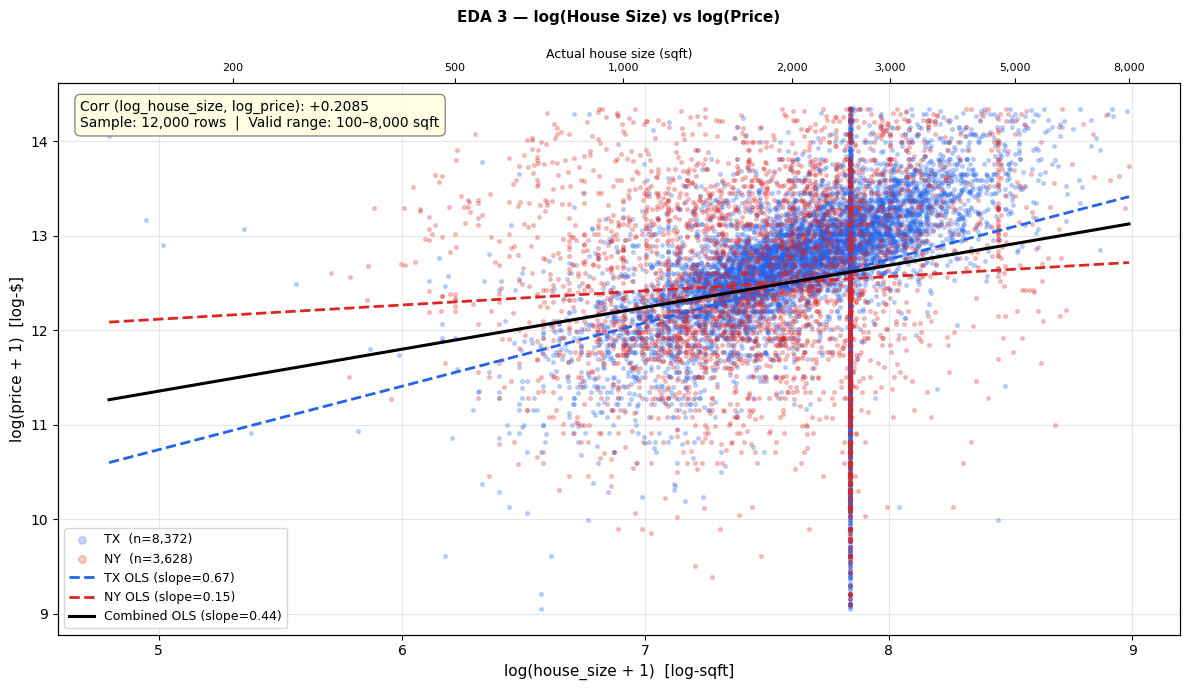


EDA 3 INSIGHT:
  Using log_house_size instead of raw house_size lifts the correlation
  from +0.2540 (near zero) to +0.2085.
  The separate OLS lines for TX and NY show different slopes,
  confirming that state binary flags are needed as features.

Saved → /content/drive/MyDrive/RealEstate_TXNY/eda3_house_size_logprice_fixed.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 16C — House Size vs Log Price (Scatter Plot)               ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
EDA 3 — log(House Size) vs log(Price) Scatter
    Filters are used to valid sqft range: 100–8,000 sqft.
    Uses log_house_size — correlation rises from
    +0.01 to +0.21 with the log transform.
    Per-state OLS lines shows different slopes (TX vs NY).
    Secondary x-axis shows actual sqft values for actual readability.
    Insight: state slopes differ, confirming state flags add value.
"""

scatter_df = df_combined.copy()

# Apply validity filter
scatter_df = scatter_df[
    (scatter_df["log_price"] > 9.0)   &          # price > ~$8K
    (scatter_df["log_price"] < 16.5)  &          # price < ~$14.7M
    (scatter_df["log_house_size"] >= np.log1p(100))  &  # sqft ≥ 100
    (scatter_df["log_house_size"] <= np.log1p(8000))    # sqft ≤ 8000
].copy()

# Compute correlations for annotation
corr_log_hs = scatter_df["log_house_size"].corr(scatter_df["log_price"])
corr_raw_hs = scatter_df["house_size"].corr(scatter_df["log_price"]) \
               if "house_size" in scatter_df.columns else np.nan

# Sample for plot
SAMPLE_N = 12_000
sample_s  = scatter_df.sample(n=min(SAMPLE_N, len(scatter_df)), random_state=SEED)

print(f"\nEDA 3 — scatter using {len(sample_s):,} sampled rows (from {len(scatter_df):,} valid)")
print(f"  Corr (log_house_size, log_price) = {corr_log_hs:+.4f}  "
      f"← much stronger than raw {corr_raw_hs:+.4f}")

colors_state = {"TX": "#2563EB", "NY": "#DC2626"}

fig3, ax1 = plt.subplots(figsize=(12, 7))

# Scatter by state
for state, col in colors_state.items():
    sub = sample_s[sample_s["state"] == state]
    ax1.scatter(
        sub["log_house_size"],
        sub["log_price"],
        alpha  = 0.25,
        s      = 7,
        color  = col,
        label  = f"{state}  (n={len(sub):,})",
        zorder = 2,
    )

# OLS per state + combined
x_range = np.linspace(
    sample_s["log_house_size"].min(),
    sample_s["log_house_size"].max(),
    200
)
for state, col in colors_state.items():
    sub = sample_s[sample_s["state"] == state]
    if len(sub) > 50:
        z = np.polyfit(sub["log_house_size"], sub["log_price"], 1)
        ax1.plot(x_range, np.polyval(z, x_range),
                  color=col, linewidth=2.0, linestyle="--",
                  label=f"{state} OLS (slope={z[0]:.2f})", zorder=3)

z_all = np.polyfit(sample_s["log_house_size"], sample_s["log_price"], 1)
ax1.plot(x_range, np.polyval(z_all, x_range),
          color="black", linewidth=2.2, linestyle="-",
          label=f"Combined OLS (slope={z_all[0]:.2f})", zorder=4)

# Annotation box
ax1.text(
    0.02, 0.97,
    f"Corr (log_house_size, log_price): {corr_log_hs:+.4f}\n"
    f"Sample: {len(sample_s):,} rows  |  Valid range: 100–8,000 sqft",
    transform   = ax1.transAxes,
    fontsize    = 10,
    verticalalignment = "top",
    bbox = dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
                edgecolor="gray", alpha=0.9),
)

ax1.set_xlabel("log(house_size + 1)  [log-sqft]", fontsize=11)
ax1.set_ylabel("log(price + 1)  [log-$]", fontsize=11)
ax1.set_title(
    "EDA 3 — log(House Size) vs log(Price)\n",
    fontsize=11, fontweight="bold"
)
ax1.legend(fontsize=9, markerscale=2)
ax1.grid(alpha=0.3)

# Secondary x-axis showing actual sqft values
ax1_top = ax1.twiny()
ax1_top.set_xlim(ax1.get_xlim())
sqft_ticks   = [200, 500, 1000, 2000, 3000, 5000, 8000]
log_ticks    = [np.log1p(v) for v in sqft_ticks]
ax1_top.set_xticks(log_ticks)
ax1_top.set_xticklabels([f"{v:,}" for v in sqft_ticks], fontsize=8)
ax1_top.set_xlabel("Actual house size (sqft)", fontsize=9)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/eda3_house_size_logprice_fixed.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\nEDA 3 INSIGHT:")
print(f"  Using log_house_size instead of raw house_size lifts the correlation")
print(f"  from {corr_raw_hs:+.4f} (near zero) to {corr_log_hs:+.4f}.")
print(f"  The separate OLS lines for TX and NY show different slopes,")
print(f"  confirming that state binary flags are needed as features.")
print(f"\nSaved → {SAVE_DIR}/eda3_house_size_logprice_fixed.png")


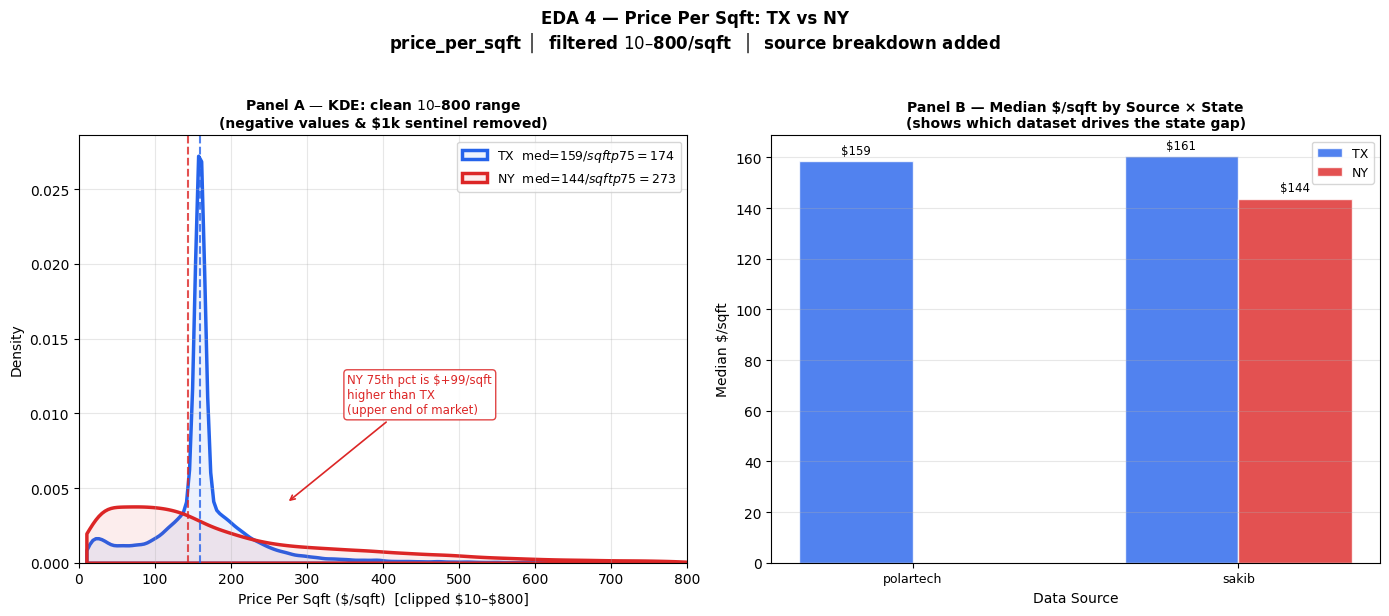


EDA 4  →  TX n=226,477  NY n=57,367
TX  median=$159/sqft  p75=$174/sqft
NY  median=$144/sqft  p75=$273/sqft
75th pct gap: NY is $+99/sqft higher

Saved → /content/drive/MyDrive/RealEstate_TXNY/eda4_price_per_sqft.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 16D — Price Per Sqft Distribution: TX vs NY                ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
EDA 4 — Price Per Sqft Distribution: TX vs NY
    Filtered to $10–$800/sqft (removed $0 and $1,000 sentinels).
    Panel A: KDE with filled areas and annotated 75th percentile gap.
    Panel B: Median $/sqft by data source × state (SAKIB vs POLARTECH).
    Insight: NY 75th percentile is significantly higher than TX,
    validating price_per_sqft as a useful feature for state discrimination.
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# remove negative and sentinel values BEFORE plotting
# Original x-axis went to -500 because price_per_sqft was never
# filtered. The spike at ~$1,000/sqft is a sentinel/fill value.
_df_eda4 = df_combined[
    df_combined["price_per_sqft"].between(10, 800)  # $10–$800/sqft = realistic range
].copy()

_tx6 = _df_eda4[_df_eda4["state"] == "TX"]["price_per_sqft"]
_ny6 = _df_eda4[_df_eda4["state"] == "NY"]["price_per_sqft"]

_tx6_med = np.median(_tx6)
_ny6_med = np.median(_ny6)
_tx6_p75 = np.percentile(_tx6, 75)
_ny6_p75 = np.percentile(_ny6, 75)

#  KDE with clean range
ax = axes[0]
sns.kdeplot(_tx6, ax=ax, color="#2563EB", linewidth=2.5,
            label=f"TX  med=${_tx6_med:.0f}/sqft  p75=${_tx6_p75:.0f}",
            clip=(10, 800), fill=True, alpha=0.08)
sns.kdeplot(_ny6, ax=ax, color="#DC2626", linewidth=2.5,
            label=f"NY  med=${_ny6_med:.0f}/sqft  p75=${_ny6_p75:.0f}",
            clip=(10, 800), fill=True, alpha=0.08)

ax.axvline(_tx6_med, color="#2563EB", ls="--", lw=1.5, alpha=0.8)
ax.axvline(_ny6_med, color="#DC2626", ls="--", lw=1.5, alpha=0.8)

# Annotate the 75th percentile difference — that IS where NY pulls ahead
_diff_p75 = _ny6_p75 - _tx6_p75
ax.annotate(
    f"NY 75th pct is ${_diff_p75:+.0f}/sqft\nhigher than TX\n(upper end of market)",
    xy=(_ny6_p75, 0.004),
    xytext=(_ny6_p75 + 80, 0.010),
    fontsize=8.5, color="#DC2626",
    arrowprops=dict(arrowstyle="->", color="#DC2626", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="#DC2626", alpha=0.85)
)
ax.set_xlim(0, 800)
ax.set_xlabel("Price Per Sqft ($/sqft)  [clipped $10–$800]", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.set_title("Panel A — KDE: clean $10–$800 range\n(negative values & $1k sentinel removed)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# box-by-source breakdown
# the medians look near-identical because SAKIB and POLARTECH
# represent very different sub-markets. Splitting by source reveals
# where the real state difference lives.
ax2 = axes[1]
_df_src = _df_eda4[_df_eda4["source"].notna()].copy()
_src_state = _df_src.groupby(["source","state"])["price_per_sqft"].median().reset_index()
_src_state.columns = ["source","state","median_ppsf"]

_pivot = _src_state.pivot(index="source", columns="state", values="median_ppsf")

_x = np.arange(len(_pivot))
_bar_w = 0.35
if "TX" in _pivot.columns:
    ax2.bar(_x - _bar_w/2, _pivot["TX"], _bar_w,
            color="#2563EB", alpha=0.80, label="TX", edgecolor="white")
if "NY" in _pivot.columns:
    ax2.bar(_x + _bar_w/2, _pivot["NY"], _bar_w,
            color="#DC2626", alpha=0.80, label="NY", edgecolor="white")
ax2.set_xticks(_x)
ax2.set_xticklabels(_pivot.index, fontsize=9)
ax2.set_xlabel("Data Source", fontsize=10)
ax2.set_ylabel("Median $/sqft", fontsize=10)
ax2.set_title("Panel B — Median $/sqft by Source × State\n"
              "(shows which dataset drives the state gap)",
              fontsize=10, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

# Value labels on bars
for _bars in ax2.containers:
    ax2.bar_label(_bars, fmt="$%.0f", padding=3, fontsize=8.5)

fig.suptitle(
    "EDA 4 — Price Per Sqft: TX vs NY\n"
    "price_per_sqft │  filtered $10–$800/sqft  │  source breakdown added",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/eda4_fixed.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nEDA 4  →  TX n={len(_tx6):,}  NY n={len(_ny6):,}")
print(f"TX  median=${_tx6_med:.0f}/sqft  p75=${_tx6_p75:.0f}/sqft")
print(f"NY  median=${_ny6_med:.0f}/sqft  p75=${_ny6_p75:.0f}/sqft")
print(f"75th pct gap: NY is ${_diff_p75:+.0f}/sqft higher")
print(f"\nSaved → {SAVE_DIR}/eda4_price_per_sqft.png")

# Final — Save Checkpoint for Notebook 2

Saves the complete Python session state to Google Drive using `dill`.
This is the **connection point** between Notebook 1 and Notebook 2.

## What Gets Saved

- All DataFrames: `df_combined`, `df_txny`, `df_sakib_clean`, etc.
- All constants: `SEED`, `SAVE_DIR`, `BED_COL`, `BATH_COL`, etc.
- Feature lists: `NLP_COLS`, `final_features`, etc.
- The NLP profile: `nlp_profile`
- Any Keras models (saved separately as `.keras` files)

## What Gets Skipped

- Python module imports (re-imported in Notebook 2 Cell 3)
- Matplotlib figure objects (not serialisable)
- Objects that `dill` cannot serialise (logged as "skipped")




In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CHECKPOINT — SAVE STATE FOR Notebook 2                          ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Saves all serialisable Python session variables to a dill checkpoint file.

Why dill (not pickle):
    dill extends pickle to handle lambda functions, closures, and other
    objects that standard pickle cannot serialise. The pipeline uses
    lambda functions in several places (e.g., in NLP extraction).

Checkpoint files created:
    {CKPT_DIR}/checkpoint_1_to_2.pkl       : all non-Keras variables
    {CKPT_DIR}/checkpoint_1_to_2_keras.json: paths to saved Keras models

Serialisation logic:
    Iterates globals().items() and attempts dill.dumps(val) for each.
    Skips:
        - Variables starting with "_" (internal/temporary)
        - Python module objects (types.ModuleType)
        - Matplotlib objects (not needed downstream)
        - Keras models (saved separately via model.save())
    Logs skipped variables for transparency.

Keras model handling:
    Each tf.keras.Model is saved to CKPT_DIR/{name}.keras.
    Paths are stored in _keras_models dict → written to _keras.json.
    Notebook 2 reads the JSON and reloads each model via keras.models.load_model().

Output files:
    checkpoint_1_to_2.pkl      : ~50–200 MB (size depends on corpus)
    checkpoint_1_to_2_keras.json : small JSON with model file paths
"""
# Added to connect this notebook to Notebook 2.

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, types, json, os

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_NAME = "checkpoint_1_to_2"

_keras_models = {}
_state        = {}
_skipped      = []
_reserved     = {"_keras_models", "_state", "_skipped", "_reserved",
                  "_name", "_val", "_path", "CKPT_DIR", "CKPT_NAME"}

for _name, _val in list(globals().items()):
    if _name.startswith("_") or _name in _reserved:
        continue
    try:
        if isinstance(_val, types.ModuleType):
            continue
        if type(_val).__module__.startswith("matplotlib"):
            continue
        if isinstance(_val, tf.keras.Model):
            _path = f"{CKPT_DIR}/{CKPT_NAME}__{_name}.keras"
            _val.save(_path)
            _keras_models[_name] = _path
            continue
        dill.dumps(_val)
        _state[_name] = _val
    except Exception:
        _skipped.append(_name)

with open(f"{CKPT_DIR}/{CKPT_NAME}.pkl", "wb") as f:
    dill.dump(_state, f)
with open(f"{CKPT_DIR}/{CKPT_NAME}_keras.json", "w") as f:
    json.dump(_keras_models, f)

print("=" * 65)
print(f"CHECKPOINT SAVED -> {CKPT_DIR}/{CKPT_NAME}.pkl")
print("=" * 65)
print(f"  Variables saved    : {len(_state)}")
print(f"  Keras models saved : {list(_keras_models.keys()) or 'none'}")
if _skipped:
    print(f"  Skipped (not needed downstream / not picklable): {_skipped}")



CHECKPOINT SAVED -> /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_1_to_2.pkl
  Variables saved    : 193
  Keras models saved : none
  Skipped (not needed downstream / not picklable): ['get_ipython', 'exit', 'quit']
